In [1]:
# Generated from output/jupyter-notebook/instance-validation-and-exploratory-analysis.ipynb
# Run as a percent script in editors that support `# %%` cells, or as plain Python.

# Experiment: Instance Validation and Exploratory Analysis

**Objetivo**

Usar o próprio notebook como workspace interativo principal para validar e explorar o release oficial `v1.1.0-observed`, reaproveitando o backend consolidado em `tools/instance_analysis_repl.py`.

**O que este notebook cobre**

- inventário do release oficial e contexto estrutural
- validação estrutural e reconciliação dos audits
- comportamento da camada observacional
- testes formais `MMD/C2ST` e proxy de `density ratio` para medir o deslocamento nominal -> observado
- auditoria relacional entre os arquivos centrais do release
- sanidade operacional por regime
- validação de caudas e segmentos raros
- cobertura do espaço de instâncias e checagem de redundância
- smoke test orientado a solver para verificar utilidade algorítmica do benchmark
- drilldown visual de uma instância concreta

**Modo de uso**

Este notebook é a interface interativa principal. O módulo `tools/instance_analysis_repl.py` funciona como backend compartilhado da análise, para evitar duas implementações diferentes do mesmo pipeline analítico.

In [2]:
# Setup: notebook runtime, paths and shared backend
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import matplotlib

NON_INTERACTIVE_CLI = __name__ == "__main__" and "ipykernel" not in sys.modules
if NON_INTERACTIVE_CLI:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from IPython.display import Markdown, display

if NON_INTERACTIVE_CLI:
    plt.show = lambda *args, **kwargs: None


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "instances").exists()
            and (candidate / "catalog").exists()
            and (candidate / "tools").exists()
        ):
            return candidate
    raise RuntimeError(
        "Could not locate repository root from current working directory."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
ARTIFACT_DIR = (
    REPO_ROOT / "output" / "jupyter-notebook" / "instance_validation_analysis_artifacts"
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TOOLS_DIR = REPO_ROOT / "tools"
if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

import instance_analysis_repl as repl
import exact_solver_smoke as solver_smoke

repl = importlib.reload(repl)
solver_smoke = importlib.reload(solver_smoke)

SEED = repl.SEED
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

STAGE_ORDER = repl.STAGE_ORDER
REGIME_ORDER = repl.REGIME_ORDER
SCALE_ORDER = repl.SCALE_ORDER


def _sample_frame(frame: pd.DataFrame, max_rows: int | None, seed: int = SEED) -> pd.DataFrame:
    if max_rows is None or len(frame) <= max_rows:
        return frame.reset_index(drop=True)
    return frame.sample(n=max_rows, random_state=seed).reset_index(drop=True)


def _prepare_feature_matrix(frame: pd.DataFrame, numeric_cols: list[str], categorical_cols: list[str]) -> pd.DataFrame:
    matrix = pd.get_dummies(
        frame[numeric_cols + categorical_cols].copy(),
        columns=categorical_cols,
        drop_first=False,
    ).astype(float)
    means = matrix.mean(axis=0)
    stds = matrix.std(axis=0, ddof=0).replace(0.0, 1.0)
    return ((matrix - means) / stds).astype("float32")


def _mmd_rbf(x: np.ndarray, y: np.ndarray, gamma: float) -> float:
    xx = ((x[:, None, :] - x[None, :, :]) ** 2).sum(axis=2)
    yy = ((y[:, None, :] - y[None, :, :]) ** 2).sum(axis=2)
    xy = ((x[:, None, :] - y[None, :, :]) ** 2).sum(axis=2)
    k_xx = np.exp(-gamma * xx)
    k_yy = np.exp(-gamma * yy)
    k_xy = np.exp(-gamma * xy)
    return float(k_xx.mean() + k_yy.mean() - 2.0 * k_xy.mean())


def _median_gamma(z: np.ndarray) -> float:
    sq = ((z[:, None, :] - z[None, :, :]) ** 2).sum(axis=2)
    tri = sq[np.triu_indices_from(sq, k=1)]
    tri = tri[tri > 0]
    if len(tri) == 0:
        return 1.0
    median_sq = float(np.median(tri))
    return 1.0 / max(2.0 * median_sq, 1e-6)


def _mmd_permutation_test(
    x: np.ndarray,
    y: np.ndarray,
    permutations: int = 80,
    seed: int = SEED,
) -> tuple[float, float]:
    combined = np.vstack([x, y])
    n_x = len(x)
    gamma = _median_gamma(combined)
    observed = _mmd_rbf(x, y, gamma)
    rng = np.random.default_rng(seed)
    perm_stats = []
    for _ in range(permutations):
        perm = rng.permutation(len(combined))
        x_perm = combined[perm[:n_x]]
        y_perm = combined[perm[n_x:]]
        perm_stats.append(_mmd_rbf(x_perm, y_perm, gamma))
    pvalue = float((np.sum(np.array(perm_stats) >= observed) + 1) / (permutations + 1))
    return observed, pvalue


def run_domain_shift_experiment(
    nominal: pd.DataFrame,
    observed: pd.DataFrame,
    numeric_cols: list[str],
    categorical_cols: list[str],
    group_cols: list[str],
    label: str,
    max_rows_per_domain: int | None = None,
    mmd_sample_cap: int = 600,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    nominal = _sample_frame(nominal.copy(), max_rows_per_domain, seed=SEED)
    observed = _sample_frame(observed.copy(), max_rows_per_domain, seed=SEED + 1)
    nominal["domain"] = "nominal"
    observed["domain"] = "observed"
    combined = pd.concat([nominal, observed], ignore_index=True)
    combined["domain_target"] = combined["domain"].eq("observed").astype(int)

    x = _prepare_feature_matrix(combined, numeric_cols=numeric_cols, categorical_cols=categorical_cols)
    y = combined["domain_target"].to_numpy()

    clf = LogisticRegression(max_iter=1500, solver="lbfgs")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    auc_scores = cross_val_score(clf, x, y, cv=cv, scoring="roc_auc")
    prob_oof = cross_val_predict(clf, x, y, cv=cv, method="predict_proba")[:, 1]
    combined["prob_observed"] = prob_oof
    prob_clipped = np.clip(prob_oof, 1e-5, 1 - 1e-5)
    combined["density_ratio_proxy"] = prob_clipped / (1 - prob_clipped)
    combined["log_density_ratio_proxy"] = np.log(combined["density_ratio_proxy"])

    nominal_x = x.loc[combined["domain"].eq("nominal")].to_numpy()
    observed_x = x.loc[combined["domain"].eq("observed")].to_numpy()
    nominal_mmd = nominal_x[: min(len(nominal_x), mmd_sample_cap)]
    observed_mmd = observed_x[: min(len(observed_x), mmd_sample_cap)]
    mmd_stat, mmd_pvalue = _mmd_permutation_test(nominal_mmd, observed_mmd)

    summary = pd.DataFrame(
        [
            {
                "experiment": label,
                "rows_per_domain": int(min(len(nominal), len(observed))),
                "feature_count": int(x.shape[1]),
                "c2st_auc_mean": float(np.mean(auc_scores)),
                "c2st_auc_std": float(np.std(auc_scores, ddof=0)),
                "c2st_auc_oof": float(roc_auc_score(y, prob_oof)),
                "mmd_rbf_stat": float(mmd_stat),
                "mmd_permutation_pvalue": float(mmd_pvalue),
            }
        ]
    )

    grouped = (
        combined.groupby(group_cols + ["domain"], as_index=False)
        .agg(
            sample_count=("domain_target", "size"),
            mean_prob_observed=("prob_observed", "mean"),
            mean_log_density_ratio=("log_density_ratio_proxy", "mean"),
        )
    )
    observed_group = grouped[grouped["domain"] == "observed"].drop(columns="domain")
    nominal_group = grouped[grouped["domain"] == "nominal"].drop(columns="domain")
    segment_shift = observed_group.merge(
        nominal_group,
        on=group_cols,
        how="outer",
        suffixes=("_observed", "_nominal"),
    )
    segment_shift["mean_prob_observed_delta"] = (
        segment_shift["mean_prob_observed_observed"] - segment_shift["mean_prob_observed_nominal"]
    )
    segment_shift["mean_log_density_ratio_delta"] = (
        segment_shift["mean_log_density_ratio_observed"] - segment_shift["mean_log_density_ratio_nominal"]
    )
    segment_shift["experiment"] = label
    return summary, segment_shift.sort_values(group_cols).reset_index(drop=True)


def build_tail_and_segment_reports(jobs_enriched: pd.DataFrame, job_metrics: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    jobs_metrics = job_metrics.merge(
        jobs_enriched[
            [
                "instance_id",
                "job_id",
                "priority_class",
                "appointment_flag",
                "moisture_class",
                "commodity",
                "due_margin_over_lb_min",
            ]
        ],
        on=["instance_id", "job_id"],
        how="left",
    )

    tail_summary = (
        jobs_metrics.groupby(["scale_code", "regime_code"], as_index=False)
        .agg(
            flow_p95=("flow_time_min", lambda s: float(np.quantile(s, 0.95))),
            flow_p99=("flow_time_min", lambda s: float(np.quantile(s, 0.99))),
            queue_p95=("queue_time_min", lambda s: float(np.quantile(s, 0.95))),
            queue_p99=("queue_time_min", lambda s: float(np.quantile(s, 0.99))),
            overwait_share=("overwait_min", lambda s: float(np.mean(np.asarray(s) > 0))),
            due_margin_p05=("due_margin_over_lb_min", lambda s: float(np.quantile(s, 0.05))),
        )
    )

    tail_checks = []
    for scale_code, frame in tail_summary.groupby("scale_code"):
        ordered = frame.set_index("regime_code").reindex(REGIME_ORDER)
        tail_checks.append(
            {
                "scale_code": scale_code,
                "flow_p99_order_ok": bool(ordered["flow_p99"].is_monotonic_increasing),
                "queue_p99_order_ok": bool(ordered["queue_p99"].is_monotonic_increasing),
                "due_margin_p05_order_ok": bool(ordered["due_margin_p05"].is_monotonic_decreasing),
            }
        )
    tail_checks = pd.DataFrame(tail_checks).sort_values("scale_code").reset_index(drop=True)

    segment_rows = []
    segment_specs = {
        "URGENT": jobs_metrics["priority_class"].eq("URGENT"),
        "WET": jobs_metrics["moisture_class"].eq("WET"),
        "APPOINTMENT": jobs_metrics["appointment_flag"].eq(1),
        "URGENT_AND_WET": jobs_metrics["priority_class"].eq("URGENT") & jobs_metrics["moisture_class"].eq("WET"),
        "APPOINTMENT_AND_WET": jobs_metrics["appointment_flag"].eq(1) & jobs_metrics["moisture_class"].eq("WET"),
    }
    for segment_label, mask in segment_specs.items():
        frame = jobs_metrics[mask].copy()
        if len(frame) == 0:
            continue
        segment_rows.append(
            {
                "segment_label": segment_label,
                "job_count": int(len(frame)),
                "job_share": float(len(frame) / len(jobs_metrics)),
                "flow_mean": float(frame["flow_time_min"].mean()),
                "flow_p95": float(np.quantile(frame["flow_time_min"], 0.95)),
                "queue_mean": float(frame["queue_time_min"].mean()),
                "queue_p95": float(np.quantile(frame["queue_time_min"], 0.95)),
                "overwait_share": float(np.mean(frame["overwait_min"] > 0)),
                "due_margin_p05": float(np.quantile(frame["due_margin_over_lb_min"], 0.05)),
            }
        )
    segment_summary = pd.DataFrame(segment_rows).sort_values("flow_p95", ascending=False).reset_index(drop=True)
    return tail_summary, tail_checks, segment_summary


def build_relational_consistency_reports(
    jobs: pd.DataFrame,
    operations: pd.DataFrame,
    precedences: pd.DataFrame,
    eligible: pd.DataFrame,
    machines: pd.DataFrame,
    events: pd.DataFrame,
    schedule: pd.DataFrame,
    job_metrics: pd.DataFrame,
    params: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for instance_id in sorted(jobs["instance_id"].unique()):
        jobs_g = jobs[jobs["instance_id"] == instance_id]
        ops_g = operations[operations["instance_id"] == instance_id]
        prec_g = precedences[precedences["instance_id"] == instance_id]
        eligible_g = eligible[eligible["instance_id"] == instance_id]
        machines_g = machines[machines["instance_id"] == instance_id]
        events_g = events[events["instance_id"] == instance_id]
        schedule_g = schedule[schedule["instance_id"] == instance_id]
        metrics_g = job_metrics[job_metrics["instance_id"] == instance_id]

        job_keys = set(jobs_g["job_id"])
        op_keys = set(map(tuple, ops_g[["job_id", "op_seq"]].itertuples(index=False, name=None)))
        machine_keys = set(machines_g["machine_id"])

        ops_per_job = ops_g.groupby("job_id").size().reindex(jobs_g["job_id"]).fillna(0)
        prec_per_job = prec_g.groupby("job_id").size().reindex(jobs_g["job_id"]).fillna(0)
        eligible_per_op = eligible_g.groupby(["job_id", "op_seq"]).size().reindex(pd.MultiIndex.from_frame(ops_g[["job_id", "op_seq"]])).fillna(0)
        schedule_per_op = schedule_g.groupby(["job_id", "op_seq"]).size().reindex(pd.MultiIndex.from_frame(ops_g[["job_id", "op_seq"]])).fillna(0)

        event_job_rows = events_g[events_g["event_type"].isin(["JOB_VISIBLE", "JOB_ARRIVAL"])]
        event_machine_rows = events_g[events_g["event_type"].isin(["MACHINE_DOWN", "MACHINE_UP"])]

        rows.append(
            {
                "instance_id": instance_id,
                "job_has_4_operations_ok": bool(ops_per_job.eq(4).all()),
                "job_has_3_precedences_ok": bool(prec_per_job.eq(3).all()),
                "every_operation_has_eligible_machine_ok": bool((eligible_per_op > 0).all()),
                "fifo_has_one_row_per_operation_ok": bool(schedule_per_op.eq(1).all() and len(schedule_g) == len(ops_g)),
                "schedule_operation_fk_ok": bool(set(map(tuple, schedule_g[["job_id", "op_seq"]].itertuples(index=False, name=None))).issubset(op_keys)),
                "schedule_machine_fk_ok": bool(set(schedule_g["machine_id"]).issubset(machine_keys)),
                "metrics_job_fk_ok": bool(set(metrics_g["job_id"]).issubset(job_keys) and len(metrics_g) == len(jobs_g)),
                "job_events_fk_ok": bool(set(event_job_rows["entity_id"]).issubset(job_keys)),
                "machine_events_fk_ok": bool(set(event_machine_rows["entity_id"]).issubset(machine_keys)),
                "job_with_wrong_op_count": int((~ops_per_job.eq(4)).sum()),
                "job_with_wrong_prec_count": int((~prec_per_job.eq(3)).sum()),
                "operations_without_eligible_machine": int((eligible_per_op <= 0).sum()),
                "operations_without_single_schedule_row": int((~schedule_per_op.eq(1)).sum()),
                "metrics_job_count_gap": int(abs(len(metrics_g) - len(jobs_g))),
            }
        )

    report = pd.DataFrame(rows).merge(
        params[["instance_id", "scale_code", "regime_code"]], on="instance_id", how="left"
    )
    bool_cols = [c for c in report.columns if c.endswith("_ok")]
    summary = pd.DataFrame(
        [
            {
                "check_name": col,
                "pass_rate": float(report[col].mean()),
                "failed_instance_count": int((~report[col]).sum()),
            }
            for col in bool_cols
        ]
    ).sort_values(["pass_rate", "check_name"], ascending=[True, True]).reset_index(drop=True)
    return report, summary

## Plan

1. Carregar o backend analítico compartilhado e expor os objetos principais no notebook.
2. Validar integridade estrutural, reconciliar audits e inspecionar métricas agregadas do release.
3. Verificar se a camada observacional reduz sobre-determinismo sem quebrar a semântica operacional.
4. Medir formalmente o deslocamento nominal -> observado e a consistência relacional do release.
5. Testar caudas, segmentos raros e monotonicidade forte por regime.
6. Confirmar que o release cobre regiões distintas do espaço de instâncias e não colapsa em casos quase redundantes.
7. Executar um smoke test exato com orçamento fixo para mostrar que o benchmark é informativo do ponto de vista algorítmico.
8. Fazer drilldown visual em uma instância para checagem manual do baseline FIFO.

In [3]:
# Bootstrap the notebook workspace from the shared REPL backend
CTX = repl.CTX
SUMMARY = repl.SUMMARY
NOTEBOOK_CTX = dict(repl.CTX)
NOTEBOOK_CTX["artifact_dir"] = ARTIFACT_DIR

params = repl.PARAMS.copy()
catalog = repl.CATALOG.copy()
family_summary = repl.FAMILY_SUMMARY.copy()
observed_noise_manifest = repl.OBSERVED_NOISE_MANIFEST
manifest = repl.MANIFEST

jobs = repl.JOBS.copy()
jobs_enriched = repl.JOBS_ENRICHED.copy()
operations = repl.OPERATIONS.copy()
eligible = repl.ELIGIBLE.copy()
machines = repl.MACHINES.copy()
precedences = repl.PRECEDENCES.copy()
downtimes = repl.DOWNTIMES.copy()
events = repl.EVENTS.copy()
schedule = repl.SCHEDULE.copy()
job_metrics = repl.JOB_METRICS.copy()
due_audit = repl.DUE_AUDIT.copy()
proc_audit = repl.PROC_AUDIT.copy()
proc_audit_enriched = repl.PROC_AUDIT_ENRICHED.copy()
congestion = repl.CONGESTION.copy()

structural_report = repl.STRUCTURAL_REPORT.copy()
event_report = repl.EVENT_REPORT.copy()
audit_reconciliation = repl.AUDIT_RECONCILIATION.copy()
regime_checks = repl.REGIME_CHECKS.copy()
fifo_schema_report = repl.FIFO_SCHEMA_REPORT.copy()
release_consistency_report = repl.RELEASE_CONSISTENCY_REPORT.copy()
utilization = repl.UTILIZATION.copy()
instance_space_features = repl.INSTANCE_SPACE_FEATURES.copy()
instance_space_pairs = repl.INSTANCE_SPACE_PAIRS.copy()
instance_space_summary = repl.INSTANCE_SPACE_SUMMARY.copy()
instance_space_knn_profile = repl.INSTANCE_SPACE_KNN_PROFILE.copy()
instance_space_knn_regime_composition = repl.INSTANCE_SPACE_KNN_REGIME_COMPOSITION.copy()
instance_space_knn_scale_composition = repl.INSTANCE_SPACE_KNN_SCALE_COMPOSITION.copy()
diagnostics = repl.DIAGNOSTICS.copy()
unload = repl.UNLOAD.copy()

validation_observed = pd.read_csv(
    REPO_ROOT / "catalog" / "validation_report_observed.csv"
)
validation_nominal_style = pd.read_csv(REPO_ROOT / "catalog" / "validation_report.csv")
g2milp_contract = json.loads(
    (REPO_ROOT / "catalog" / "g2milp_generation_contract.json").read_text(
        encoding="utf-8"
    )
)

inventory_summary = pd.DataFrame([SUMMARY])
display(inventory_summary)
display(
    Markdown(
        """
**Quick start interativo**

- `SUMMARY`
- `params.head()`
- `structural_report.head()`
- `repl.plot_inventory_overview()`
- `repl.plot_validation_overview()`
- `repl.plot_observational_layer()`
- `repl.plot_congestion_diagnostics()`
- `repl.plot_operational_sanity()`
- `repl.plot_instance_space_coverage()`
- `repl.plot_instance_drilldown("GO_XS_DISRUPTED_01")`
"""
    )
)

,dataset_version,instance_count,job_count,operation_count,eligible_rows,machine_rows,structural_pass_rate,release_consistency_checks_pass,due_audit_match_share,proc_audit_match_share,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture,fifo_schema_checks_pass,flow_regime_order_checks_pass,queue_regime_order_checks_pass,congestion_mean_regime_order_checks_pass,instance_space_exact_duplicate_checks_pass,instance_space_duplicate_like_checks_pass,instance_space_nearest_neighbor_distance_min,g2milp_role
0,1.1.0-observed,36,1848,7392,21167,306,1.0,True,1.0,1.0,0.4848,0.4995,True,True,True,False,True,True,2.322821,base_dataset_for_g2milp_instance_generation



**Quick start interativo**

- `SUMMARY`
- `params.head()`
- `structural_report.head()`
- `repl.plot_inventory_overview()`
- `repl.plot_validation_overview()`
- `repl.plot_observational_layer()`
- `repl.plot_congestion_diagnostics()`
- `repl.plot_operational_sanity()`
- `repl.plot_instance_space_coverage()`
- `repl.plot_instance_drilldown("GO_XS_DISRUPTED_01")`


In [4]:
# Release metadata and provenance checks
noise_manifest_summary = pd.DataFrame(
    [
        {
            "dataset_version": manifest["dataset_version"],
            "official_dataset_role": manifest["official_dataset_role"],
            "noise_model_id": observed_noise_manifest.get("model_id"),
            "noise_global_seed": observed_noise_manifest.get("global_seed"),
            "parent_dataset_version": manifest.get("parent_dataset_version"),
            "generator_model": observed_noise_manifest.get(
                "generator_model", "ChatGPT 5.4 PRO"
            ),
        }
    ]
)

display(params.head())
display(noise_manifest_summary)
display(release_consistency_report)
display(pd.DataFrame([g2milp_contract]).iloc[:, :8])

release_consistency_report.to_csv(
    ARTIFACT_DIR / "release_consistency_report.csv", index=False
)

,dataset_name,dataset_version,instance_id,scale_code,regime_code,replicate,random_seed,time_unit,load_unit,currency,planning_horizon_min,shift_open_min,shift_close_min,antt_statutory_wait_limit_min,antt_wait_cost_rs_per_ton_hour,notes,parent_dataset_version,observational_noise_model_id,observational_noise_seed
0,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_01,L,balanced,1,41111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,817207134
1,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_02,L,balanced,2,42111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,3851404905
2,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_03,L,balanced,3,43111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,482397280
3,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_DISRUPTED_01,L,disrupted,1,41333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,569216366
4,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_DISRUPTED_02,L,disrupted,2,42333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,1131596359


,dataset_version,official_dataset_role,noise_model_id,noise_global_seed,parent_dataset_version,generator_model
0,1.1.0-observed,base_dataset_for_g2milp_instance_generation,pequiflux_observed_noise_v1_1,20260327,1.0.0,ChatGPT 5.4 PRO


,check_name,expected,observed,pass
0,manifest_dataset_version_matches_instance_params,1.1.0-observed,1.1.0-observed,True
1,manifest_parent_dataset_version_matches_instan...,1.0.0,1.0.0,True
2,manifest_noise_model_id_matches_instance_params,pequiflux_observed_noise_v1_1,pequiflux_observed_noise_v1_1,True
3,noise_manifest_model_id_matches_root_manifest,pequiflux_observed_noise_v1_1,pequiflux_observed_noise_v1_1,True
4,noise_manifest_repository_url_matches_root_man...,https://github.com/PequiFlux/agro_yard_dfjsp_b...,https://github.com/PequiFlux/agro_yard_dfjsp_b...,True
5,noise_manifest_release_root_matches_repo_root,/home/marcusvinicius/Repositorios/PequiFlux/ag...,/home/marcusvinicius/Repositorios/PequiFlux/ag...,True
6,noise_manifest_generated_with_matches_root_man...,ChatGPT 5.4 PRO,ChatGPT 5.4 PRO,True


,official_dataset_role,parent_dataset_version,generator_model_family,dataset_is_frozen_parent,required_child_lineage_fields,minimum_child_validation_requirements,documentation_ref
0,base_dataset_for_g2milp_instance_generation,1.1.0-observed,G2MILP,True,"[parent_dataset_name, parent_dataset_version, ...",[four_operations_per_job_or_declared_structura...,docs/g2milp_generation_contract.md


**Como ler as tabelas acima**

- `noise_manifest_summary` resume a versão oficial, a linhagem e o modelo gerador da camada observacional
- `release_consistency_report` formaliza a governança do release: `manifest.json` raiz, `params.json` das instâncias e `observed_noise_manifest.json`
- para publicação, o desejável é que todos os checks dessa tabela estejam em `pass = True`
- no release oficial atual, isso de fato ocorre; em particular, não há divergência entre a `dataset_version` do `manifest.json` raiz e a `dataset_version` declarada nos `params.json`

## Inventory and structural context

Esta seção responde:

- quantas instâncias, jobs, operações, máquinas e linhas elegíveis existem
- como as famílias `XS/S/M/L` e os regimes `balanced/peak/disrupted` estão distribuídos
- se os artefatos de auditoria e catálogo estão completos

,instance_id,relative_path,scale_code,regime_code,replicate,random_seed,n_jobs,n_machines,n_scales,n_labs,n_hoppers,n_breakdowns,share_urgent,share_appointment,avg_load_tons,avg_unload_proc_time_min,fifo_makespan_min,fifo_mean_flow_min,fifo_p95_flow_min,fifo_overwait_share,recommended_solver_track
0,GO_L_BALANCED_01,instances/GO_L_BALANCED_01,L,balanced,1,41111,72,13,4,3,6,0,0.0278,0.7500,38.78,24.08,670,52.99,68,0.0,metaheuristic
1,GO_L_BALANCED_02,instances/GO_L_BALANCED_02,L,balanced,2,42111,72,13,4,3,6,0,0.0278,0.7500,37.89,24.33,681,58.69,87,0.0,metaheuristic
2,GO_L_BALANCED_03,instances/GO_L_BALANCED_03,L,balanced,3,43111,72,13,4,3,6,0,0.0278,0.7500,38.81,25.91,655,50.44,57,0.0,metaheuristic
3,GO_L_DISRUPTED_01,instances/GO_L_DISRUPTED_01,L,disrupted,1,41333,96,13,4,3,6,3,0.1979,0.5938,38.57,28.56,617,101.03,148,0.0,metaheuristic
4,GO_L_DISRUPTED_02,instances/GO_L_DISRUPTED_02,L,disrupted,2,42333,96,13,4,3,6,2,0.1771,0.6354,37.85,24.08,591,93.40,150,0.0,metaheuristic
5,GO_L_DISRUPTED_03,instances/GO_L_DISRUPTED_03,L,disrupted,3,43333,96,13,4,3,6,2,0.1875,0.5938,37.96,25.93,601,93.71,141,0.0,metaheuristic
6,GO_L_PEAK_01,instances/GO_L_PEAK_01,L,peak,1,41222,96,13,4,3,6,0,0.0833,0.6562,38.25,25.81,643,94.60,163,0.0,metaheuristic
7,GO_L_PEAK_02,instances/GO_L_PEAK_02,L,peak,2,42222,96,13,4,3,6,0,0.1354,0.7083,38.06,25.49,662,73.54,112,0.0,metaheuristic
8,GO_L_PEAK_03,instances/GO_L_PEAK_03,L,peak,3,43222,96,13,4,3,6,0,0.0729,0.6354,38.07,23.50,671,78.89,127,0.0,metaheuristic
9,GO_M_BALANCED_01,instances/GO_M_BALANCED_01,M,balanced,1,31111,48,9,3,2,4,0,0.0417,0.7292,37.79,27.74,673,55.35,68,0.0,hybrid


,scale_code,regime_code,instance_count,avg_n_jobs,avg_fifo_makespan_min,avg_fifo_mean_flow_min,avg_fifo_p95_flow_min,avg_fifo_overwait_share
0,L,balanced,3,72.0,668.67,54.04,70.67,0.00
1,L,disrupted,3,96.0,603.00,96.05,146.33,0.00
2,L,peak,3,96.0,658.67,82.34,134.00,0.00
3,M,balanced,3,48.0,677.00,54.52,66.33,0.00
4,M,disrupted,3,64.0,615.00,97.68,145.00,0.00
5,M,peak,3,64.0,646.33,71.02,106.33,0.00
6,S,balanced,3,30.0,690.00,59.10,78.33,0.00
7,S,disrupted,3,40.0,598.33,89.06,142.00,0.00
8,S,peak,3,40.0,632.33,74.23,107.67,0.00
9,XS,balanced,3,18.0,645.00,73.57,100.00,0.00


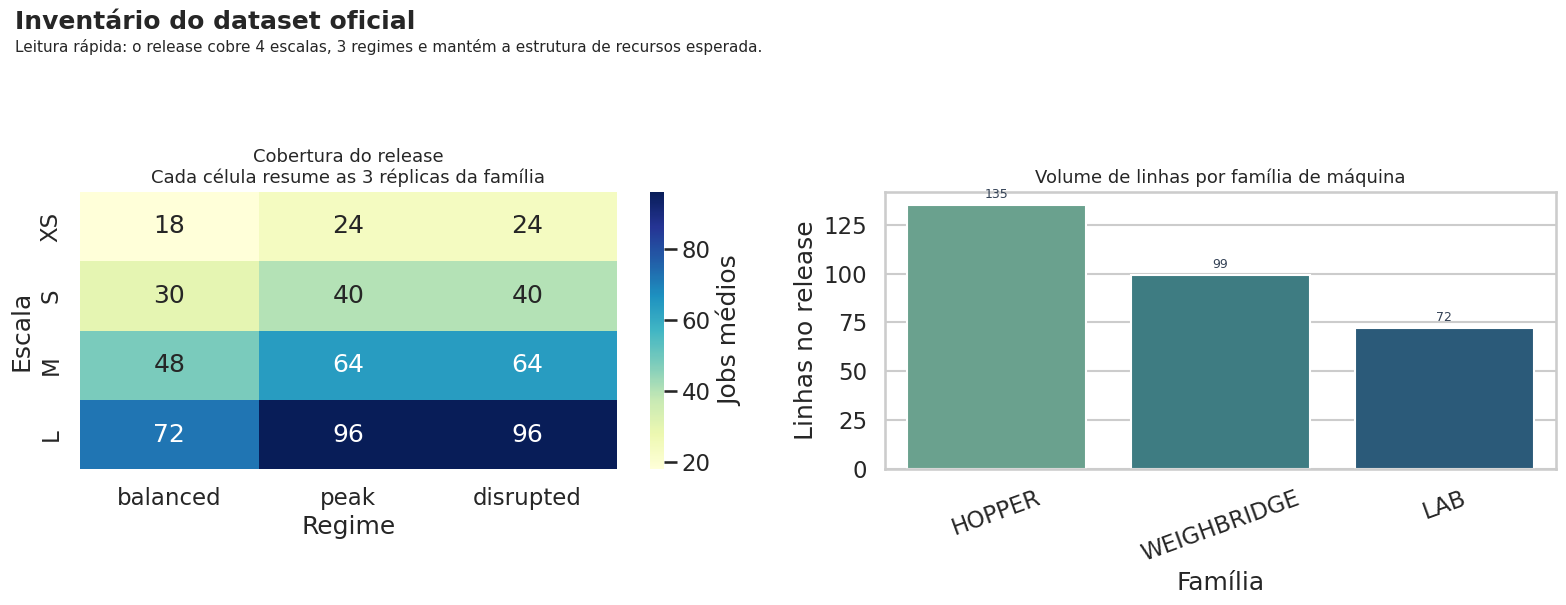

In [5]:
display(catalog.sort_values(["scale_code", "regime_code", "replicate"]).head(12))
display(family_summary.sort_values(["scale_code", "regime_code"]))

fig = repl.plot_inventory_overview(ctx=NOTEBOOK_CTX, save=True)
plt.show()

**Como ler a figura acima**

- o heatmap da esquerda mostra cobertura do release por família `escala x regime`
- as barras da direita mostram quantas linhas de recurso existem por família de máquina no release consolidado
- a figura serve como checagem de inventário, não de desempenho

## Structural validation and auditability

Aqui reaplicamos o verificador estrutural do release e complementamos com:

- executabilidade formal do baseline FIFO contra o schema
- consistência de eventos
- margem do prazo sobre o lower bound nominal
- reconciliação auditável entre arquivos centrais e CSVs de audit

,instance_id,issue_count,issues,status,scale_code,regime_code
0,GO_L_BALANCED_01,0,,PASS,L,balanced
1,GO_L_BALANCED_02,0,,PASS,L,balanced
2,GO_L_BALANCED_03,0,,PASS,L,balanced
3,GO_L_DISRUPTED_01,0,,PASS,L,disrupted
4,GO_L_DISRUPTED_02,0,,PASS,L,disrupted
5,GO_L_DISRUPTED_03,0,,PASS,L,disrupted
6,GO_L_PEAK_01,0,,PASS,L,peak
7,GO_L_PEAK_02,0,,PASS,L,peak
8,GO_L_PEAK_03,0,,PASS,L,peak
9,GO_M_BALANCED_01,0,,PASS,M,balanced


,instance_id,eligible_assignment_ok,release_time_ok,precedence_ok,machine_overlap_ok,downtime_ok,ineligible_assignments,release_time_violations,precedence_violations,machine_overlap_violations,downtime_violations,scale_code,regime_code
0,GO_L_BALANCED_01,True,True,True,True,True,0,0,0,0,0,L,balanced
1,GO_L_BALANCED_02,True,True,True,True,True,0,0,0,0,0,L,balanced
2,GO_L_BALANCED_03,True,True,True,True,True,0,0,0,0,0,L,balanced
3,GO_L_DISRUPTED_01,True,True,True,True,True,0,0,0,0,0,L,disrupted
4,GO_L_DISRUPTED_02,True,True,True,True,True,0,0,0,0,0,L,disrupted
5,GO_L_DISRUPTED_03,True,True,True,True,True,0,0,0,0,0,L,disrupted
6,GO_L_PEAK_01,True,True,True,True,True,0,0,0,0,0,L,peak
7,GO_L_PEAK_02,True,True,True,True,True,0,0,0,0,0,L,peak
8,GO_L_PEAK_03,True,True,True,True,True,0,0,0,0,0,L,peak
9,GO_M_BALANCED_01,True,True,True,True,True,0,0,0,0,0,M,balanced


,instance_id,job_visible_mismatch,job_arrival_mismatch,machine_down_missing,machine_up_missing,scale_code,regime_code
0,GO_L_BALANCED_01,0,0,0,0,L,balanced
1,GO_L_BALANCED_02,0,0,0,0,L,balanced
2,GO_L_BALANCED_03,0,0,0,0,L,balanced
3,GO_L_DISRUPTED_01,0,0,0,0,L,disrupted
4,GO_L_DISRUPTED_02,0,0,0,0,L,disrupted
5,GO_L_DISRUPTED_03,0,0,0,0,L,disrupted
6,GO_L_PEAK_01,0,0,0,0,L,peak
7,GO_L_PEAK_02,0,0,0,0,L,peak
8,GO_L_PEAK_03,0,0,0,0,L,peak
9,GO_M_BALANCED_01,0,0,0,0,M,balanced


,instance_id,due_match_share,proc_match_share,scale_code,regime_code
0,GO_L_BALANCED_01,1.0,1.0,L,balanced
1,GO_L_BALANCED_02,1.0,1.0,L,balanced
2,GO_L_BALANCED_03,1.0,1.0,L,balanced
3,GO_L_DISRUPTED_01,1.0,1.0,L,disrupted
4,GO_L_DISRUPTED_02,1.0,1.0,L,disrupted
5,GO_L_DISRUPTED_03,1.0,1.0,L,disrupted
6,GO_L_PEAK_01,1.0,1.0,L,peak
7,GO_L_PEAK_02,1.0,1.0,L,peak
8,GO_L_PEAK_03,1.0,1.0,L,peak
9,GO_M_BALANCED_01,1.0,1.0,M,balanced


,index,scale_code,regime_code,mean,min,median,max
0,0,L,balanced,249.80,154,251.0,301
1,1,L,disrupted,258.99,141,264.0,353
2,2,L,peak,257.97,172,264.0,314
3,3,M,balanced,239.47,146,243.0,295
4,4,M,disrupted,262.74,158,269.0,331
5,5,M,peak,246.40,162,249.0,327
6,6,S,balanced,248.60,179,254.5,288
7,7,S,disrupted,255.80,189,261.0,331
8,8,S,peak,246.94,173,254.0,300
9,9,XS,balanced,233.09,169,237.5,268


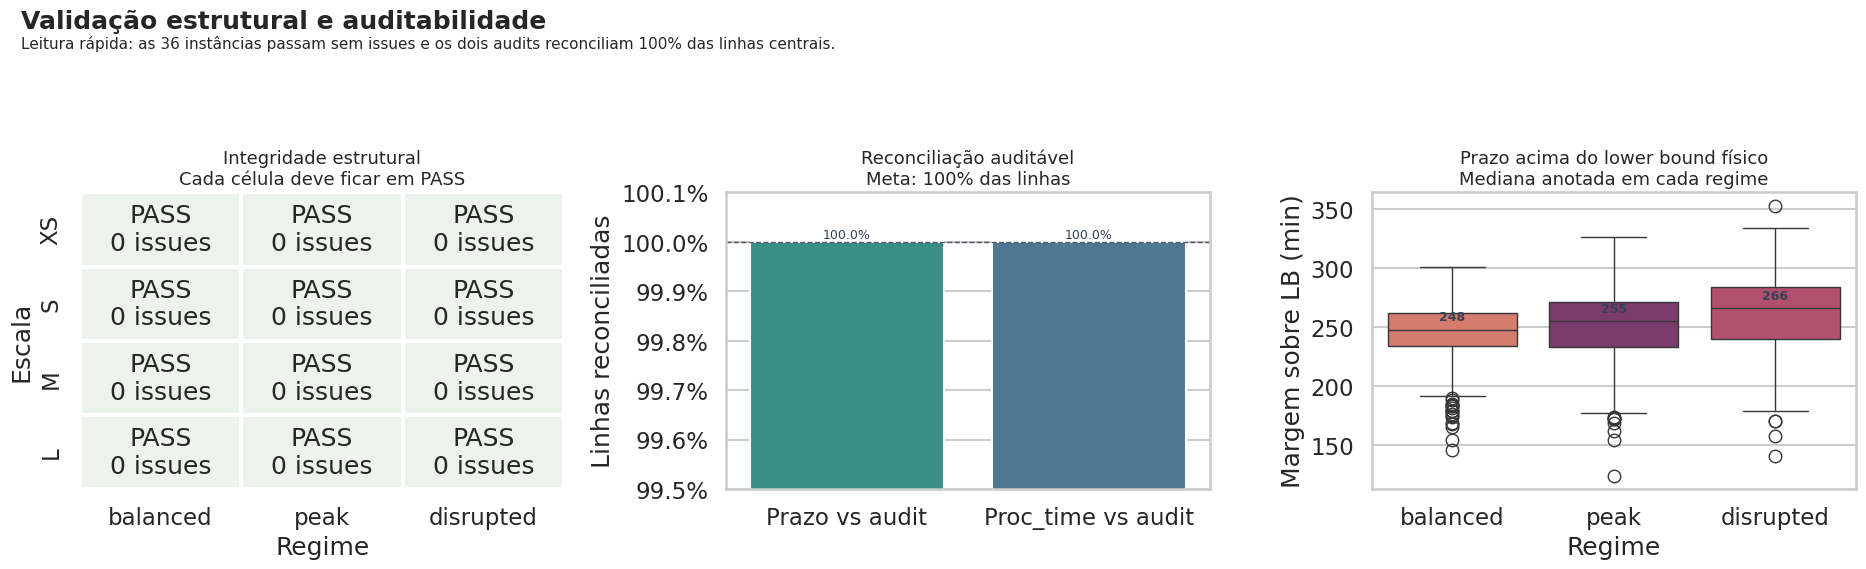

In [6]:
# The shared REPL backend already ships these reports with scale/regime context.

display(structural_report.sort_values(["scale_code", "regime_code", "instance_id"]))
display(fifo_schema_report.sort_values(["scale_code", "regime_code", "instance_id"]))
display(event_report.sort_values(["scale_code", "regime_code", "instance_id"]))
display(audit_reconciliation.sort_values(["scale_code", "regime_code", "instance_id"]))

due_margin_summary = (
    jobs_enriched.groupby(["scale_code", "regime_code"], as_index=False)[
        "due_margin_over_lb_min"
    ]
    .agg(["mean", "min", "median", "max"])
    .round(2)
    .reset_index()
)
display(due_margin_summary)

fig = repl.plot_validation_overview(ctx=NOTEBOOK_CTX, save=True)
plt.show()

structural_report.to_csv(ARTIFACT_DIR / "structural_report.csv", index=False)
fifo_schema_report.to_csv(ARTIFACT_DIR / "fifo_schema_report.csv", index=False)
event_report.to_csv(ARTIFACT_DIR / "event_report.csv", index=False)
audit_reconciliation.to_csv(ARTIFACT_DIR / "audit_reconciliation.csv", index=False)
due_margin_summary.to_csv(ARTIFACT_DIR / "due_margin_summary.csv", index=False)

**Como ler a figura acima**

- painel esquerdo: cada célula deve ficar em `PASS`; se aparecer número de issues, aquela família tem falhas estruturais
- a tabela `fifo_schema_report` formaliza a executabilidade do baseline FIFO: elegibilidade, `release_time`, precedência, overlap e downtime
- painel central: os dois bars precisam ficar em `100%`; qualquer queda indica quebra entre CSV central e CSV de audit
- painel direito: mostra quanta folga de prazo sobra acima do lower bound físico plausível

## Relational consistency across core files

A validação estrutural garante executabilidade, mas ainda vale explicitar se os
arquivos do release continuam coerentes entre si como estrutura relacional.
Aqui verificamos:

- cardinalidade `job -> 4 operações`
- cardinalidade `job -> 3 precedências`
- completude de elegibilidade por operação
- integridade referencial entre `schedule`, `machines`, `job_metrics` e `events`
- unicidade do mapeamento `operação -> linha do FIFO`

,check_name,pass_rate,failed_instance_count
0,every_operation_has_eligible_machine_ok,1.0,0
1,fifo_has_one_row_per_operation_ok,1.0,0
2,job_events_fk_ok,1.0,0
3,job_has_3_precedences_ok,1.0,0
4,job_has_4_operations_ok,1.0,0
5,machine_events_fk_ok,1.0,0
6,metrics_job_fk_ok,1.0,0
7,schedule_machine_fk_ok,1.0,0
8,schedule_operation_fk_ok,1.0,0


,instance_id,job_has_4_operations_ok,job_has_3_precedences_ok,every_operation_has_eligible_machine_ok,fifo_has_one_row_per_operation_ok,schedule_operation_fk_ok,schedule_machine_fk_ok,metrics_job_fk_ok,job_events_fk_ok,machine_events_fk_ok,job_with_wrong_op_count,job_with_wrong_prec_count,operations_without_eligible_machine,operations_without_single_schedule_row,metrics_job_count_gap,scale_code,regime_code
0,GO_L_BALANCED_01,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,balanced
1,GO_L_BALANCED_02,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,balanced
2,GO_L_BALANCED_03,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,balanced
3,GO_L_DISRUPTED_01,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,disrupted
4,GO_L_DISRUPTED_02,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,disrupted
5,GO_L_DISRUPTED_03,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,disrupted
6,GO_L_PEAK_01,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,peak
7,GO_L_PEAK_02,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,peak
8,GO_L_PEAK_03,True,True,True,True,True,True,True,True,True,0,0,0,0,0,L,peak
9,GO_M_BALANCED_01,True,True,True,True,True,True,True,True,True,0,0,0,0,0,M,balanced


/tmp/ipykernel_2225256/944616438.py:74: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=(0, 0, 1, 0.92))


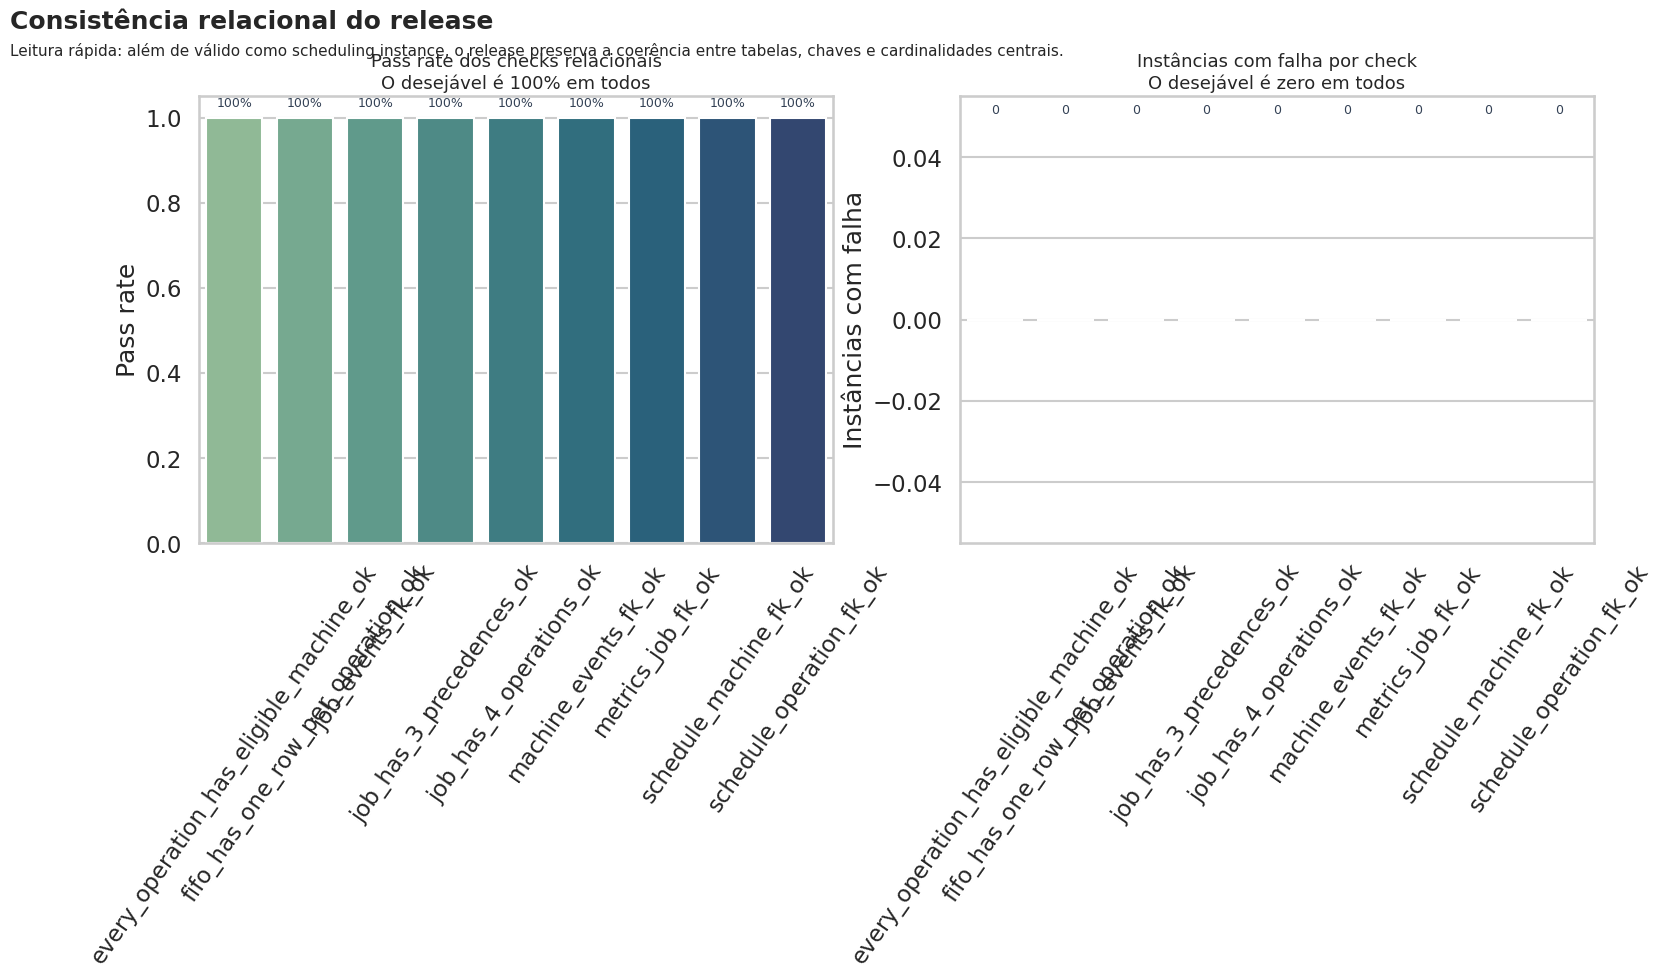

In [7]:
relational_consistency_report, relational_consistency_summary = build_relational_consistency_reports(
    jobs=jobs,
    operations=operations,
    precedences=precedences,
    eligible=eligible,
    machines=machines,
    events=events,
    schedule=schedule,
    job_metrics=job_metrics,
    params=params,
)
display(relational_consistency_summary)
display(relational_consistency_report.sort_values(["scale_code", "regime_code", "instance_id"]))

fig, axes = plt.subplots(1, 2, figsize=(18, 5.8))
sns.barplot(
    data=relational_consistency_summary,
    x="check_name",
    y="pass_rate",
    hue="check_name",
    dodge=False,
    legend=False,
    palette="crest",
    ax=axes[0],
)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Pass rate dos checks relacionais\nO desejável é 100% em todos", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Pass rate")
axes[0].tick_params(axis="x", rotation=55)
for patch, value in zip(axes[0].patches, relational_consistency_summary["pass_rate"]):
    axes[0].text(
        patch.get_x() + patch.get_width() / 2,
        value + 0.02,
        f"{value:.0%}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#334155",
    )

sns.barplot(
    data=relational_consistency_summary,
    x="check_name",
    y="failed_instance_count",
    hue="check_name",
    dodge=False,
    legend=False,
    palette="flare",
    ax=axes[1],
)
axes[1].set_title("Instâncias com falha por check\nO desejável é zero em todos", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("Instâncias com falha")
axes[1].tick_params(axis="x", rotation=55)
for patch, value in zip(axes[1].patches, relational_consistency_summary["failed_instance_count"]):
    axes[1].text(
        patch.get_x() + patch.get_width() / 2,
        value + 0.05,
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#334155",
    )

fig.suptitle("Consistência relacional do release", x=0.02, y=1.03, ha="left", fontsize=18, fontweight="bold")
fig.text(
    0.02,
    0.95,
    "Leitura rápida: além de válido como scheduling instance, o release preserva a coerência entre tabelas, chaves e cardinalidades centrais.",
    fontsize=11,
)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(ARTIFACT_DIR / "relational_consistency_overview.png", dpi=160, bbox_inches="tight")
plt.show()

relational_consistency_report.to_csv(ARTIFACT_DIR / "relational_consistency_report.csv", index=False)
relational_consistency_summary.to_csv(ARTIFACT_DIR / "relational_consistency_summary.csv", index=False)

**Como ler a figura acima**

- o painel esquerdo mostra a taxa de aprovação dos checks relacionais; para publicação formal, o desejável é `100%`
- o painel direito mostra quantas instâncias falham em cada check; o desejável é `0`
- esta seção complementa a integridade estrutural: ela mostra que os arquivos do release não estão apenas “bem formatados”, mas também coerentes como sistema relacional


## Observational layer behavior

Esta seção testa se a camada observacional cumpriu seu papel:

- a prioridade continua importante, mas não perfeitamente determinística
- tempos de `UNLOAD` continuam interpretáveis por carga, máquina, umidade e congestionamento
- o ruído aparece de forma estruturada, e não como barulho arbitrário

,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture
0,0.4848,0.4995


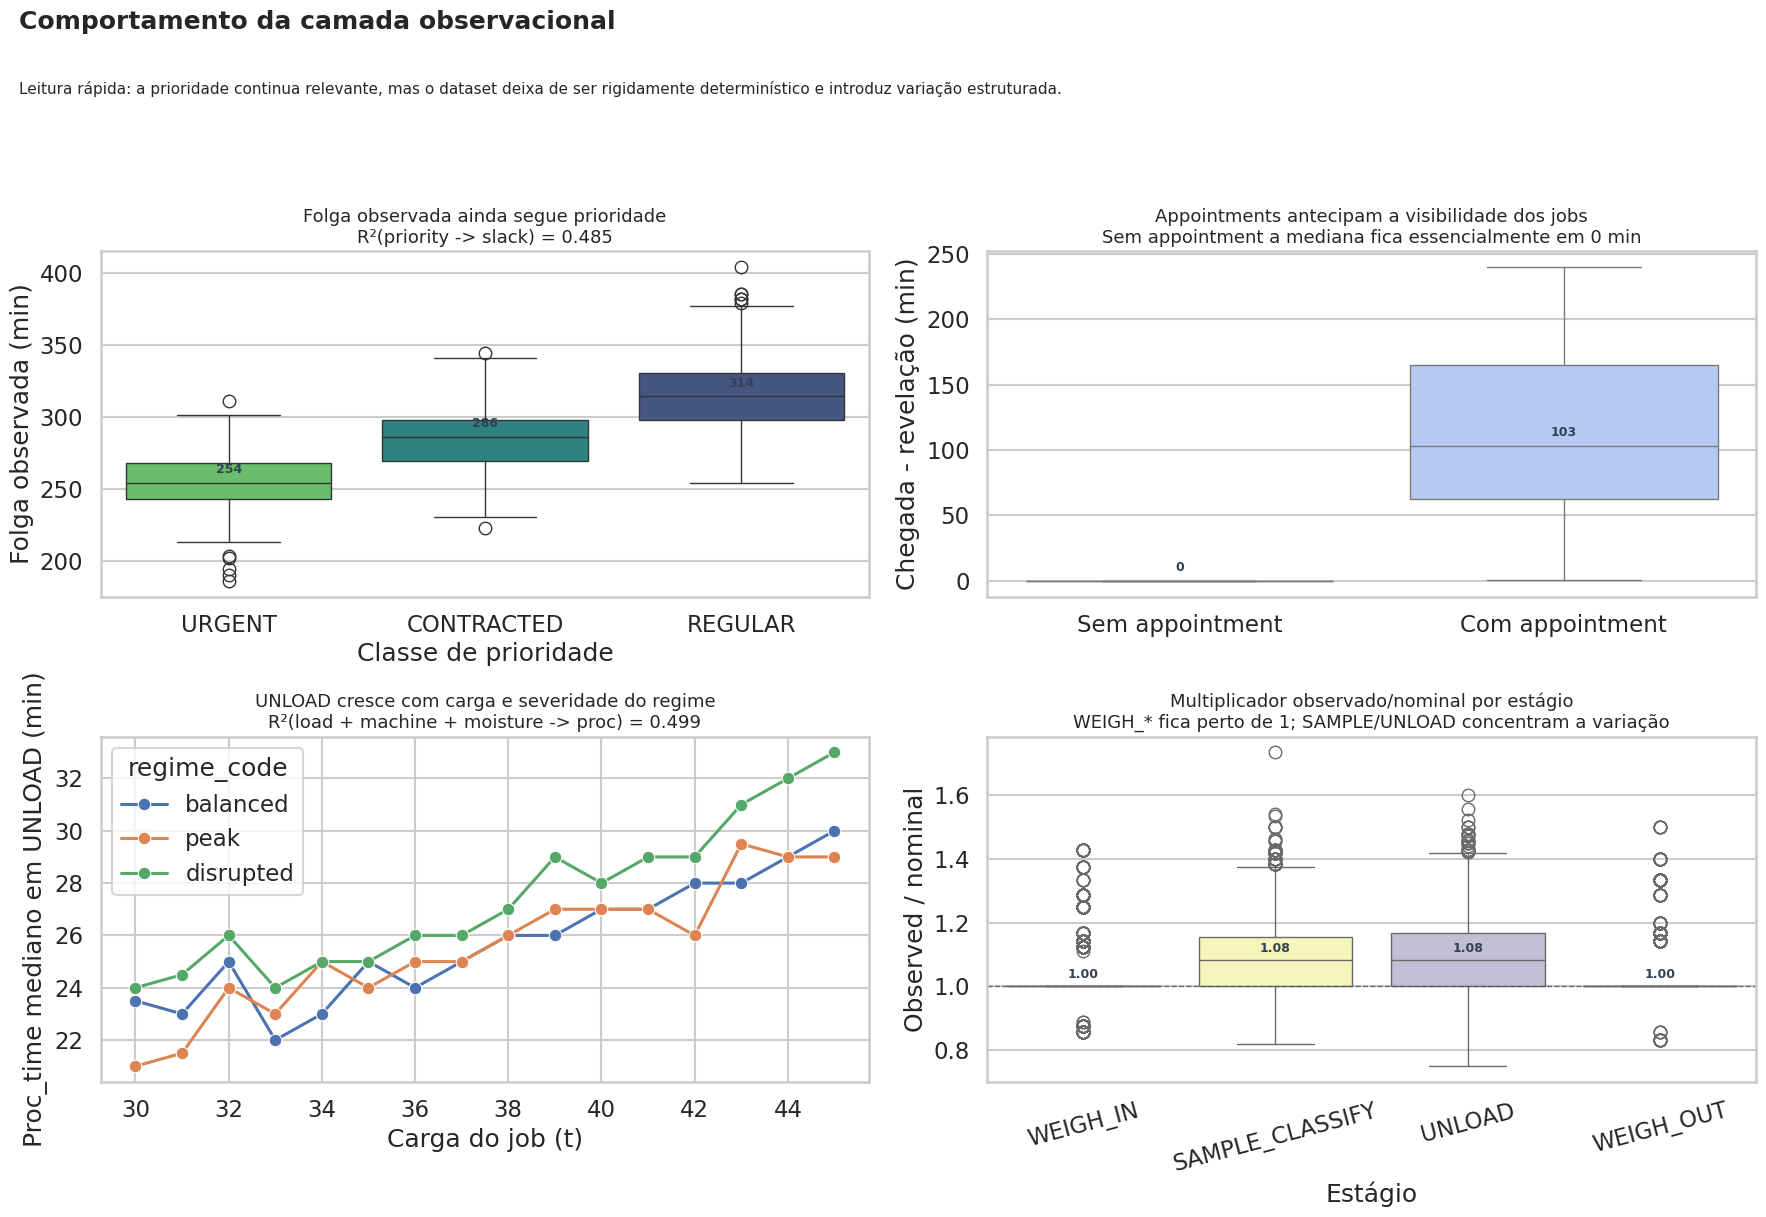

In [8]:
diagnostics_df = pd.DataFrame([diagnostics])
display(diagnostics_df)

fig = repl.plot_observational_layer(ctx=NOTEBOOK_CTX, save=True)
plt.show()

**Como ler a figura acima**

- prioridade ainda ordena a folga de prazo, mas o `R²` abaixo de `0.5` mostra que ela não explica tudo sozinha
- `appointment` afeta visibilidade antes da chegada, o que ajuda a aproximar o benchmark de uma operação real
- em `UNLOAD`, a carga e o regime empurram o tempo mediano para cima
- os multiplicadores por estágio mostram onde a camada observacional realmente introduziu variação

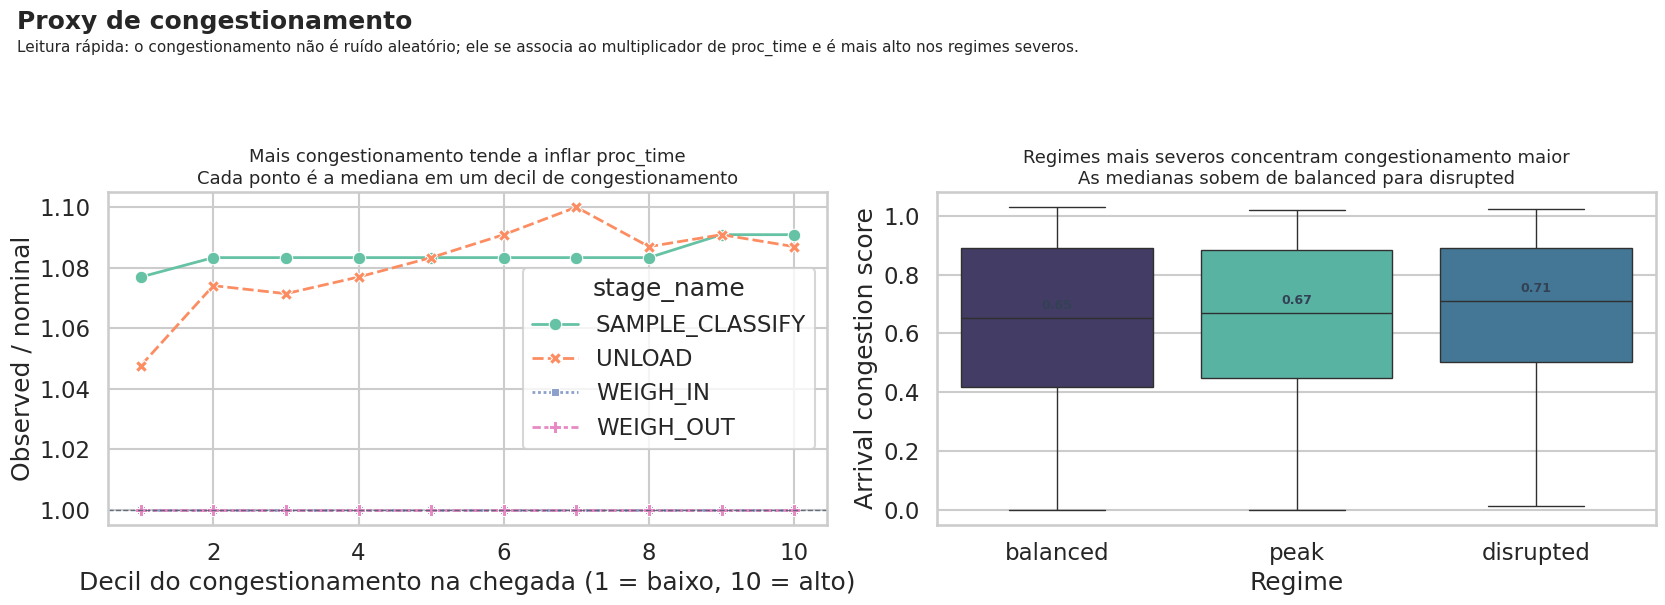

In [9]:
fig = repl.plot_congestion_diagnostics(ctx=NOTEBOOK_CTX, save=True)
plt.show()

**Como ler a figura acima**

- no painel esquerdo, cada linha resume um estágio por decil de congestionamento; inclinação positiva significa que o proxy está influenciando `proc_time`
- no painel direito, `balanced`, `peak` e `disrupted` deveriam deslocar a distribuição para cima nessa ordem

## Formal two-sample tests for the observational layer

Os gráficos anteriores mostram a camada observacional de forma intuitiva. Aqui,
adicionamos testes formais inspirados na literatura de avaliação de dados
sintéticos, mas adaptados ao que é viável com os artefatos já presentes no repo.

Como não temos um `holdout real` dentro deste repositório, os testes abaixo medem
o deslocamento entre a visão `nominal` e a visão `observada` do mesmo benchmark.
Eles ajudam a responder se a transformação introduziu mudança detectável, porém
ainda estruturada e semanticamente legível.

,experiment,rows_per_domain,feature_count,c2st_auc_mean,c2st_auc_std,c2st_auc_oof,mmd_rbf_stat,mmd_permutation_pvalue
0,job_due_layer,1848,22,0.777706,0.013218,0.777503,0.005687,0.012346
1,proc_time_layer,4000,23,0.597995,0.024802,0.597218,0.000980,0.765432


,regime_code,priority_class,sample_count_observed,mean_prob_observed_observed,mean_log_density_ratio_observed,sample_count_nominal,mean_prob_observed_nominal,mean_log_density_ratio_nominal,mean_prob_observed_delta,mean_log_density_ratio_delta,experiment
0,balanced,CONTRACTED,74,0.500958,0.020130,74,0.492433,-0.030241,0.008525,0.050371,job_due_layer
1,balanced,REGULAR,405,0.513417,0.065761,405,0.491647,-0.035532,0.021770,0.101293,job_due_layer
2,balanced,URGENT,25,0.398265,-0.564030,25,0.542412,0.173959,-0.144147,-0.737989,job_due_layer
3,disrupted,CONTRACTED,106,0.696375,1.130970,106,0.290461,-0.938352,0.405914,2.069322,job_due_layer
4,disrupted,REGULAR,443,0.736101,1.456798,443,0.266740,-1.048640,0.469362,2.505438,job_due_layer
5,disrupted,URGENT,123,0.687355,1.088060,123,0.320044,-0.777173,0.367312,1.865233,job_due_layer
6,peak,CONTRACTED,121,0.625581,0.709534,121,0.388203,-0.476974,0.237378,1.186508,job_due_layer
7,peak,REGULAR,474,0.612732,0.626407,474,0.385511,-0.491194,0.227221,1.117601,job_due_layer
8,peak,URGENT,77,0.587862,0.420509,77,0.414732,-0.357115,0.173130,0.777624,job_due_layer


,regime_code,stage_name,sample_count_observed,mean_prob_observed_observed,mean_log_density_ratio_observed,sample_count_nominal,mean_prob_observed_nominal,mean_log_density_ratio_nominal,mean_prob_observed_delta,mean_log_density_ratio_delta,experiment
0,balanced,SAMPLE_CLASSIFY,228,0.498368,-0.006509,219,0.467725,-0.131008,0.030642,0.124500,proc_time_layer
1,balanced,UNLOAD,293,0.546249,0.217511,268,0.489478,-0.040345,0.056771,0.257857,proc_time_layer
2,balanced,WEIGH_IN,313,0.515925,0.064363,297,0.511195,0.044805,0.004730,0.019558,proc_time_layer
3,balanced,WEIGH_OUT,311,0.529258,0.118093,303,0.526705,0.107888,0.002553,0.010204,proc_time_layer
4,disrupted,SAMPLE_CLASSIFY,261,0.541554,0.173043,294,0.458869,-0.168036,0.082685,0.341079,proc_time_layer
5,disrupted,UNLOAD,374,0.569131,0.336639,357,0.469746,-0.124592,0.099386,0.461231,proc_time_layer
6,disrupted,WEIGH_IN,388,0.498827,-0.005181,399,0.480141,-0.080742,0.018686,0.075561,proc_time_layer
7,disrupted,WEIGH_OUT,406,0.503561,0.014202,365,0.500732,0.002890,0.002828,0.011312,proc_time_layer
8,peak,SAMPLE_CLASSIFY,282,0.489760,-0.041113,301,0.463310,-0.149109,0.026450,0.107997,proc_time_layer
9,peak,UNLOAD,377,0.521404,0.106350,394,0.451103,-0.206452,0.070302,0.312802,proc_time_layer


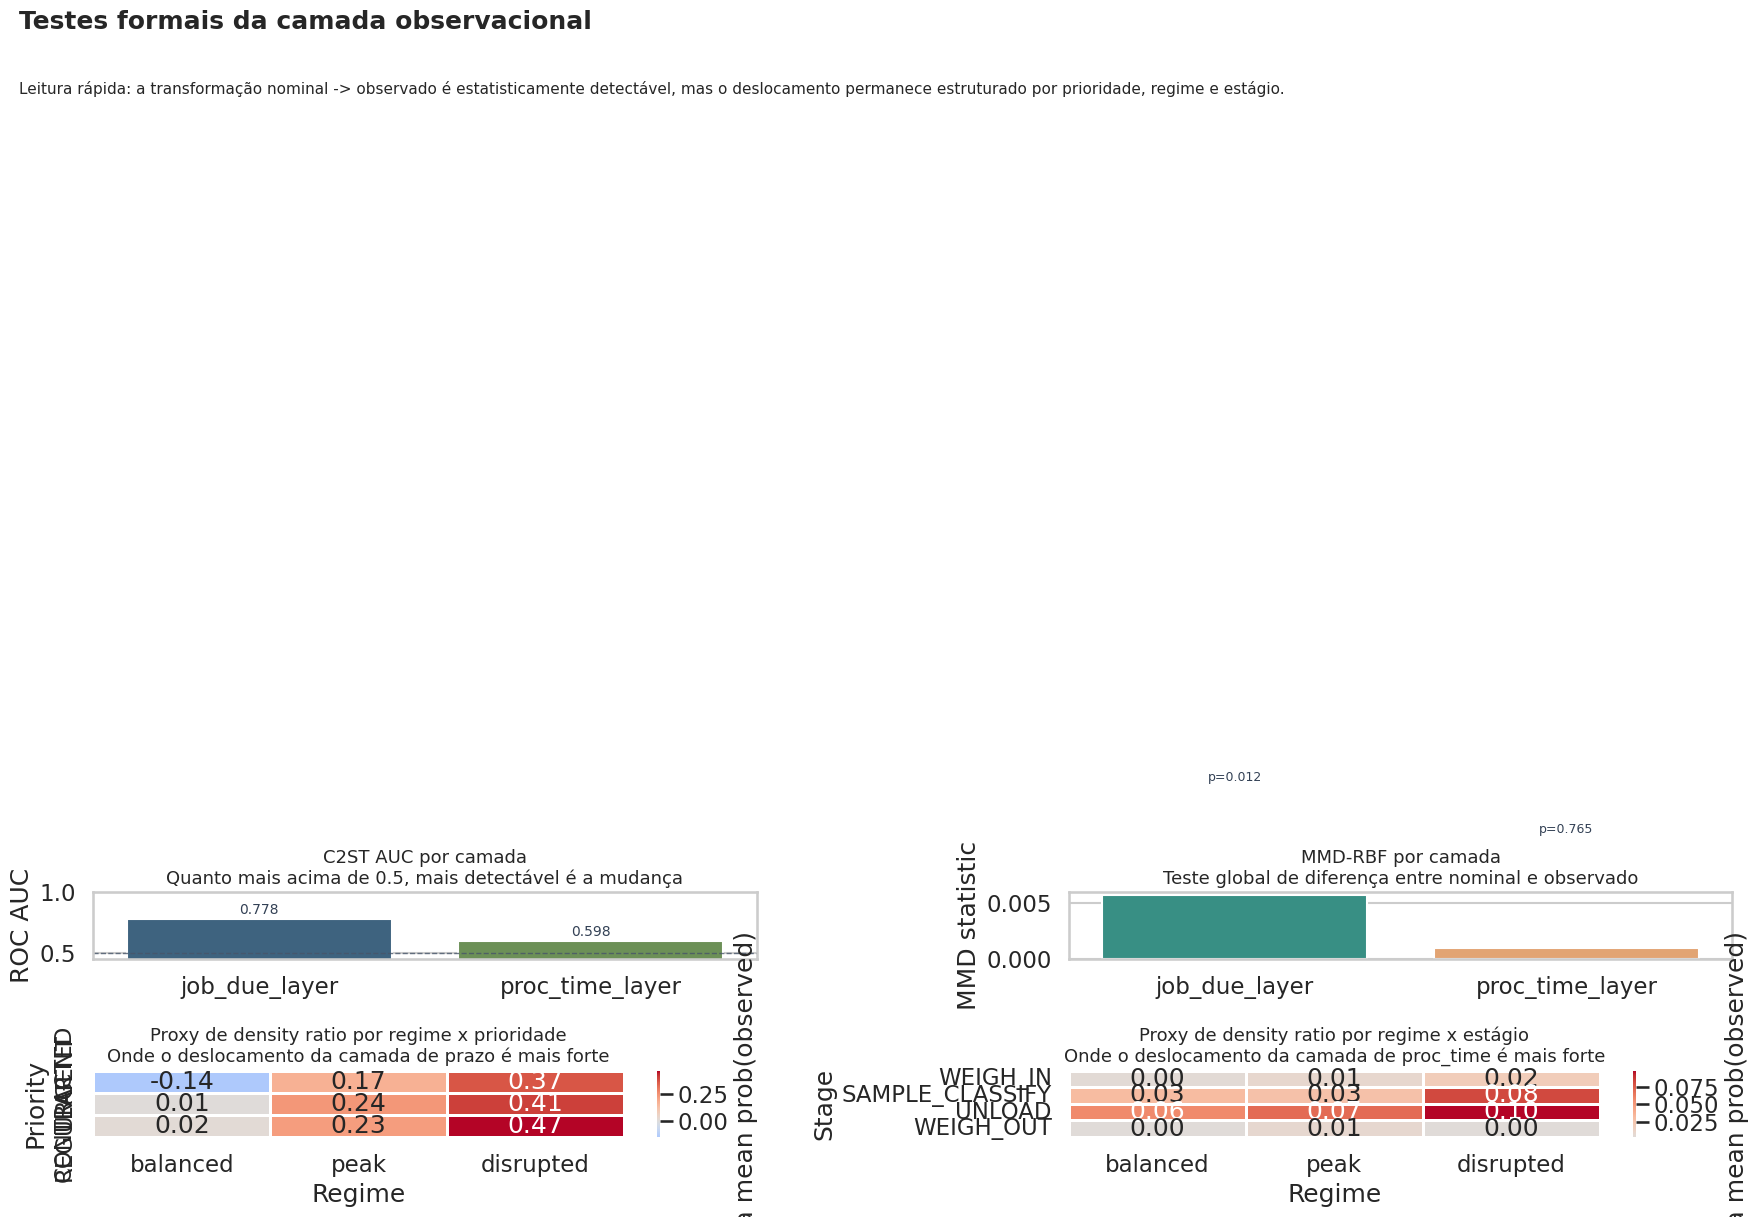

In [10]:
job_domain_base = (
    due_audit.merge(
        jobs[
            [
                "instance_id",
                "job_id",
                "load_tons",
                "priority_class",
                "appointment_flag",
                "moisture_class",
            ]
        ],
        on=["instance_id", "job_id"],
        how="left",
    )
)
job_domain_nominal = job_domain_base.assign(due_slack_min=job_domain_base["due_slack_nominal_min"])
job_domain_observed = job_domain_base.assign(due_slack_min=job_domain_base["due_slack_observed_min"])

proc_domain_base = proc_audit.copy()
proc_domain_nominal = proc_domain_base.assign(proc_time_min=proc_domain_base["proc_time_nominal_min"])
proc_domain_observed = proc_domain_base.assign(proc_time_min=proc_domain_base["proc_time_observed_min"])

job_shift_summary, job_density_segments = run_domain_shift_experiment(
    nominal=job_domain_nominal,
    observed=job_domain_observed,
    numeric_cols=["arrival_time_min", "load_tons", "due_slack_min", "nominal_processing_lb_min"],
    categorical_cols=["priority_class", "appointment_flag", "moisture_class", "shift_bucket", "scale_code", "regime_code"],
    group_cols=["regime_code", "priority_class"],
    label="job_due_layer",
    max_rows_per_domain=None,
    mmd_sample_cap=600,
)
proc_shift_summary, proc_density_segments = run_domain_shift_experiment(
    nominal=proc_domain_nominal,
    observed=proc_domain_observed,
    numeric_cols=["proc_time_min", "arrival_congestion_score", "additive_pause_min"],
    categorical_cols=["stage_name", "commodity", "moisture_class", "shift_bucket", "scale_code", "regime_code"],
    group_cols=["regime_code", "stage_name"],
    label="proc_time_layer",
    max_rows_per_domain=4000,
    mmd_sample_cap=600,
)

formal_shift_summary = pd.concat([job_shift_summary, proc_shift_summary], ignore_index=True)
display(formal_shift_summary)
display(job_density_segments.sort_values(["regime_code", "priority_class"]))
display(proc_density_segments.sort_values(["regime_code", "stage_name"]))

job_delta_heatmap = (
    job_density_segments.pivot(index="priority_class", columns="regime_code", values="mean_prob_observed_delta")
    .reindex(index=repl.PRIORITY_ORDER, columns=REGIME_ORDER)
)
proc_delta_heatmap = (
    proc_density_segments.pivot(index="stage_name", columns="regime_code", values="mean_prob_observed_delta")
    .reindex(index=STAGE_ORDER, columns=REGIME_ORDER)
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(
    data=formal_shift_summary,
    x="experiment",
    y="c2st_auc_mean",
    hue="experiment",
    dodge=False,
    legend=False,
    palette=["#33658a", "#6a994e"],
    ax=axes[0, 0],
)
axes[0, 0].axhline(0.5, color="#475569", linestyle="--", linewidth=1.0, alpha=0.8)
axes[0, 0].set_ylim(0.45, max(1.0, float(formal_shift_summary["c2st_auc_mean"].max()) + 0.05))
axes[0, 0].set_title("C2ST AUC por camada\nQuanto mais acima de 0.5, mais detectável é a mudança", fontsize=13)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("ROC AUC")
for patch, value in zip(axes[0, 0].patches, formal_shift_summary["c2st_auc_mean"]):
    axes[0, 0].text(
        patch.get_x() + patch.get_width() / 2,
        value + 0.015,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#334155",
    )

sns.barplot(
    data=formal_shift_summary,
    x="experiment",
    y="mmd_rbf_stat",
    hue="experiment",
    dodge=False,
    legend=False,
    palette=["#2a9d8f", "#f4a261"],
    ax=axes[0, 1],
)
axes[0, 1].set_title("MMD-RBF por camada\nTeste global de diferença entre nominal e observado", fontsize=13)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("MMD statistic")
for patch, (_, row) in zip(axes[0, 1].patches, formal_shift_summary.iterrows()):
    axes[0, 1].text(
        patch.get_x() + patch.get_width() / 2,
        float(row["mmd_rbf_stat"]) + 0.01,
        f"p={row['mmd_permutation_pvalue']:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#334155",
    )

sns.heatmap(
    job_delta_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0.0,
    linewidths=1.0,
    linecolor="white",
    cbar_kws={"label": "Delta mean prob(observed)"},
    ax=axes[1, 0],
)
axes[1, 0].set_title("Proxy de density ratio por regime x prioridade\nOnde o deslocamento da camada de prazo é mais forte", fontsize=13)
axes[1, 0].set_xlabel("Regime")
axes[1, 0].set_ylabel("Priority")

sns.heatmap(
    proc_delta_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0.0,
    linewidths=1.0,
    linecolor="white",
    cbar_kws={"label": "Delta mean prob(observed)"},
    ax=axes[1, 1],
)
axes[1, 1].set_title("Proxy de density ratio por regime x estágio\nOnde o deslocamento da camada de proc_time é mais forte", fontsize=13)
axes[1, 1].set_xlabel("Regime")
axes[1, 1].set_ylabel("Stage")

fig.suptitle("Testes formais da camada observacional", x=0.02, y=1.02, ha="left", fontsize=18, fontweight="bold")
fig.text(
    0.02,
    0.95,
    "Leitura rápida: a transformação nominal -> observado é estatisticamente detectável, mas o deslocamento permanece estruturado por prioridade, regime e estágio.",
    fontsize=11,
)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(ARTIFACT_DIR / "formal_shift_experiments.png", dpi=160, bbox_inches="tight")
plt.show()

formal_shift_summary.to_csv(ARTIFACT_DIR / "formal_shift_experiments_summary.csv", index=False)
job_density_segments.to_csv(ARTIFACT_DIR / "job_density_ratio_segments.csv", index=False)
proc_density_segments.to_csv(ARTIFACT_DIR / "proc_density_ratio_segments.csv", index=False)

**Como ler a figura acima**

- `C2ST` mede o quão fácil é distinguir `nominal` de `observed`; valores acima de `0.5` indicam mudança detectável
- `MMD` mede a diferença global entre distribuições; `p-values` pequenos indicam que o deslocamento é estatisticamente real
- os heatmaps inferiores funcionam como um proxy de `density ratio`: eles mostram em quais combinações de `regime x prioridade` e `regime x estágio` a transformação ficou mais forte
- a leitura desejada não é “mudança zero”; é “mudança detectável e interpretável”, sem colapso semântico da estrutura original

## Operational performance and regime sanity

A validação não depende só de integridade estrutural. Também interessa saber se:

- `balanced < peak < disrupted` permanece verdadeiro para `mean_flow` e `p95_flow`
- a fila média também preserva monotonicidade
- o proxy médio de congestionamento não precisa ser monotônico em todas as famílias
- os tempos de fluxo e fila continuam coerentes com a escala do problema
- a utilização de recurso faz sentido por família de máquina

,scale_code,mean_flow_order_ok,p95_flow_order_ok,mean_queue_order_ok,mean_congestion_order_ok
0,L,True,True,True,True
1,M,True,True,True,False
2,S,True,True,True,True
3,XS,True,True,True,True


,scale_code,regime_code,instance_count,avg_n_jobs,avg_fifo_makespan_min,avg_fifo_mean_flow_min,avg_fifo_p95_flow_min,avg_fifo_overwait_share
0,L,balanced,3,72.0,668.67,54.04,70.67,0.00
1,L,disrupted,3,96.0,603.00,96.05,146.33,0.00
2,L,peak,3,96.0,658.67,82.34,134.00,0.00
3,M,balanced,3,48.0,677.00,54.52,66.33,0.00
4,M,disrupted,3,64.0,615.00,97.68,145.00,0.00
5,M,peak,3,64.0,646.33,71.02,106.33,0.00
6,S,balanced,3,30.0,690.00,59.10,78.33,0.00
7,S,disrupted,3,40.0,598.33,89.06,142.00,0.00
8,S,peak,3,40.0,632.33,74.23,107.67,0.00
9,XS,balanced,3,18.0,645.00,73.57,100.00,0.00


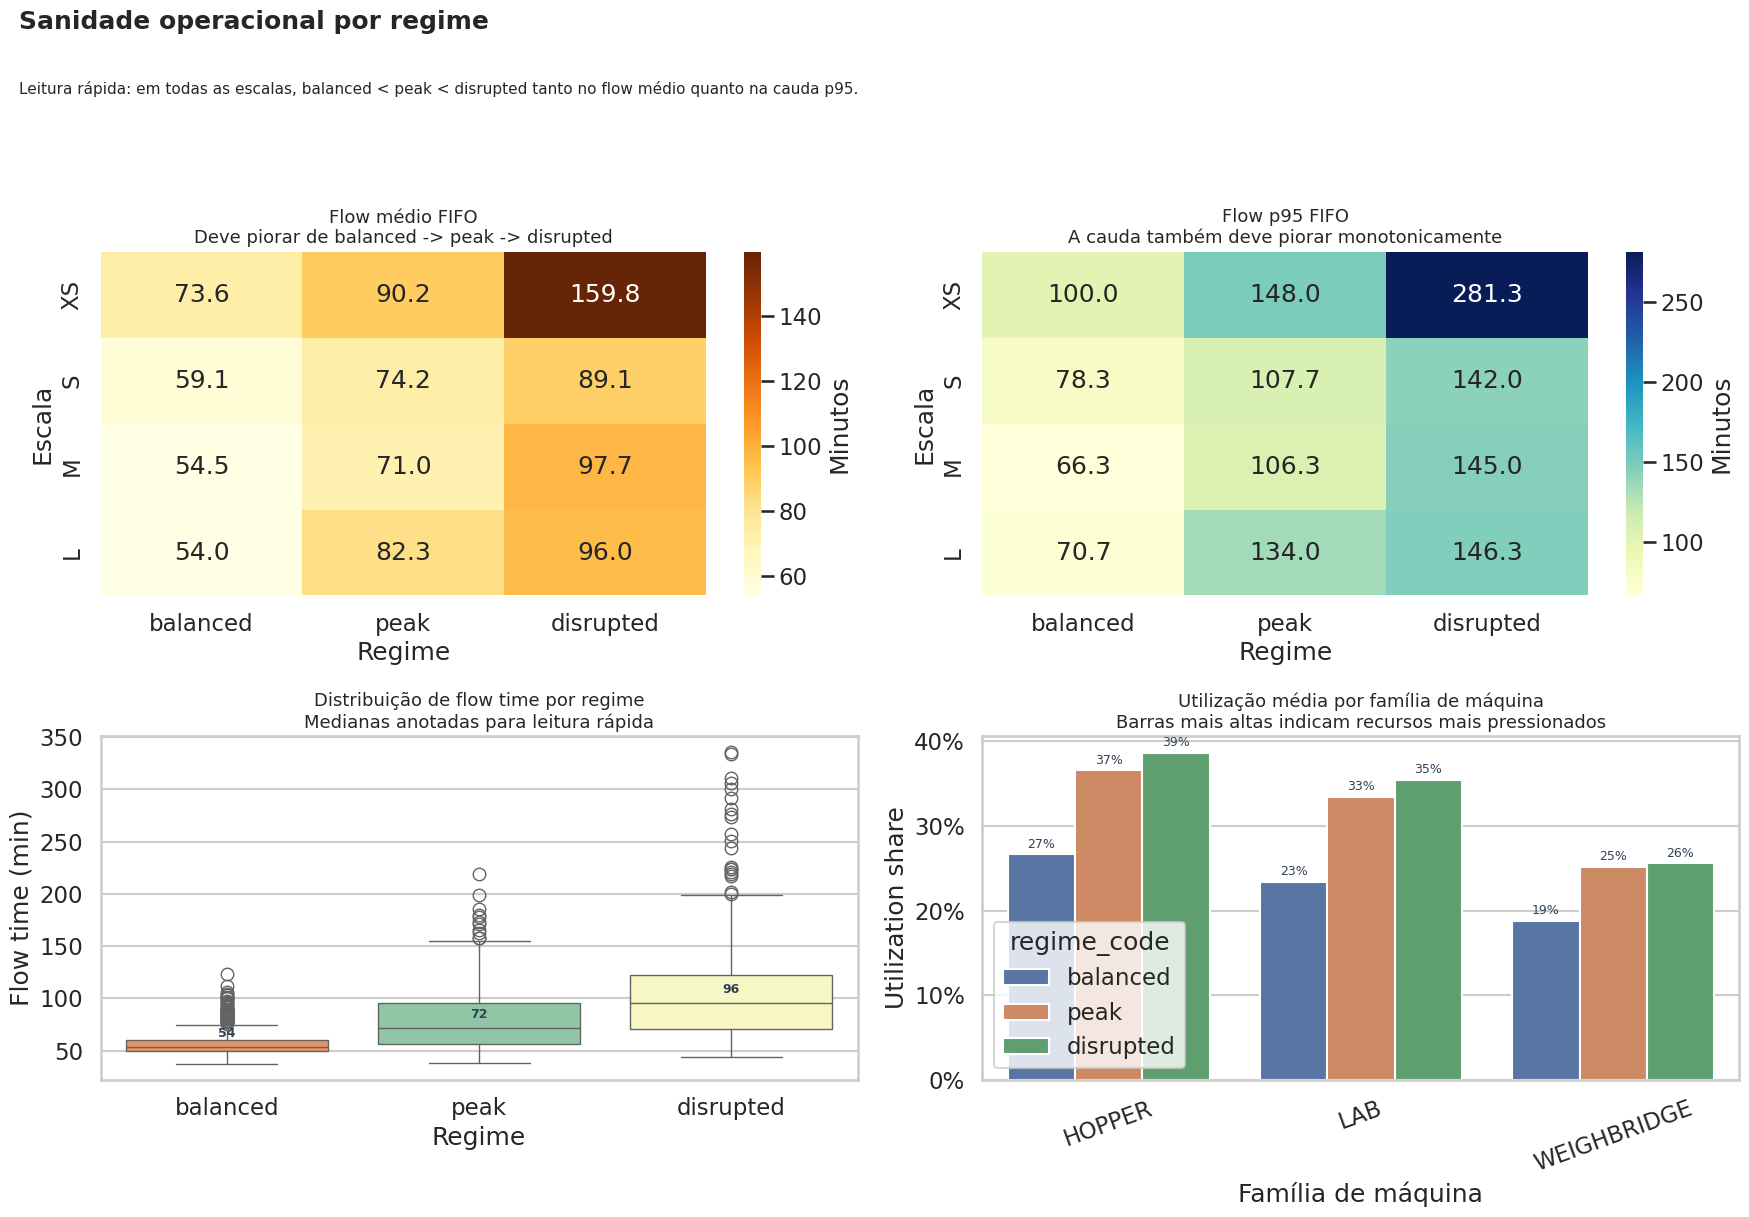

In [11]:
display(regime_checks)
display(family_summary.sort_values(["scale_code", "regime_code"]))

fig = repl.plot_operational_sanity(ctx=NOTEBOOK_CTX, save=True)
plt.show()

**Como ler a figura acima**

- os heatmaps do topo validam a monotonicidade esperada apenas para `flow`: `balanced < peak < disrupted`
- a tabela `regime_checks` separa formalmente os checks de `flow`, `queue` e `congestion`
- o boxplot inferior esquerdo mostra a distribuição de `flow_time` no nível de job
- o gráfico inferior direito ajuda a ver quais famílias de máquina absorvem mais pressão em cada regime

## Tail behavior and rare segments

Médias e medianas ajudam, mas não são suficientes para validar um benchmark
sintético operacional. Também interessa saber:

- se as caudas `p95/p99` continuam obedecendo o gradiente de regime
- se a margem sobre o lower bound continua plausível nos piores casos
- se segmentos raros, como `URGENT` e `WET`, permanecem operacionais e não colapsam em artefatos estranhos

,scale_code,regime_code,flow_p95,flow_p99,queue_p95,queue_p99,overwait_share,due_margin_p05
0,L,balanced,74.25,89.00,25.00,38.55,0.000000,210.25
1,L,disrupted,147.30,159.00,94.00,102.52,0.000000,195.00
2,L,peak,138.55,171.26,87.90,116.52,0.000000,205.35
3,M,balanced,67.85,71.85,13.70,24.57,0.000000,188.30
4,M,disrupted,151.25,163.18,97.00,108.18,0.000000,199.10
5,M,peak,116.45,127.18,57.35,70.00,0.000000,192.55
6,S,balanced,84.10,96.77,27.75,35.88,0.000000,187.60
7,S,disrupted,147.10,158.24,88.05,102.05,0.000000,198.90
8,S,peak,111.15,121.43,54.05,64.81,0.000000,190.90
9,XS,balanced,104.70,117.17,46.35,60.28,0.000000,196.25


,scale_code,flow_p99_order_ok,queue_p99_order_ok,due_margin_p05_order_ok
0,L,False,False,True
1,M,True,True,False
2,S,True,True,False
3,XS,True,True,False


,segment_label,job_count,job_share,flow_mean,flow_p95,queue_mean,queue_p95,overwait_share,due_margin_p05
0,WET,573,0.310065,89.951134,154.0,31.657941,92.4,0.001745,199.6
1,APPOINTMENT_AND_WET,361,0.195346,87.520776,151.0,29.620499,88.0,0.000000,193.0
2,URGENT,225,0.121753,85.506667,149.0,31.653333,97.0,0.004444,170.4
3,APPOINTMENT,1219,0.659632,79.863823,143.0,26.924528,88.0,0.002461,192.0
4,URGENT_AND_WET,75,0.040584,86.506667,141.3,28.013333,79.9,0.000000,169.7


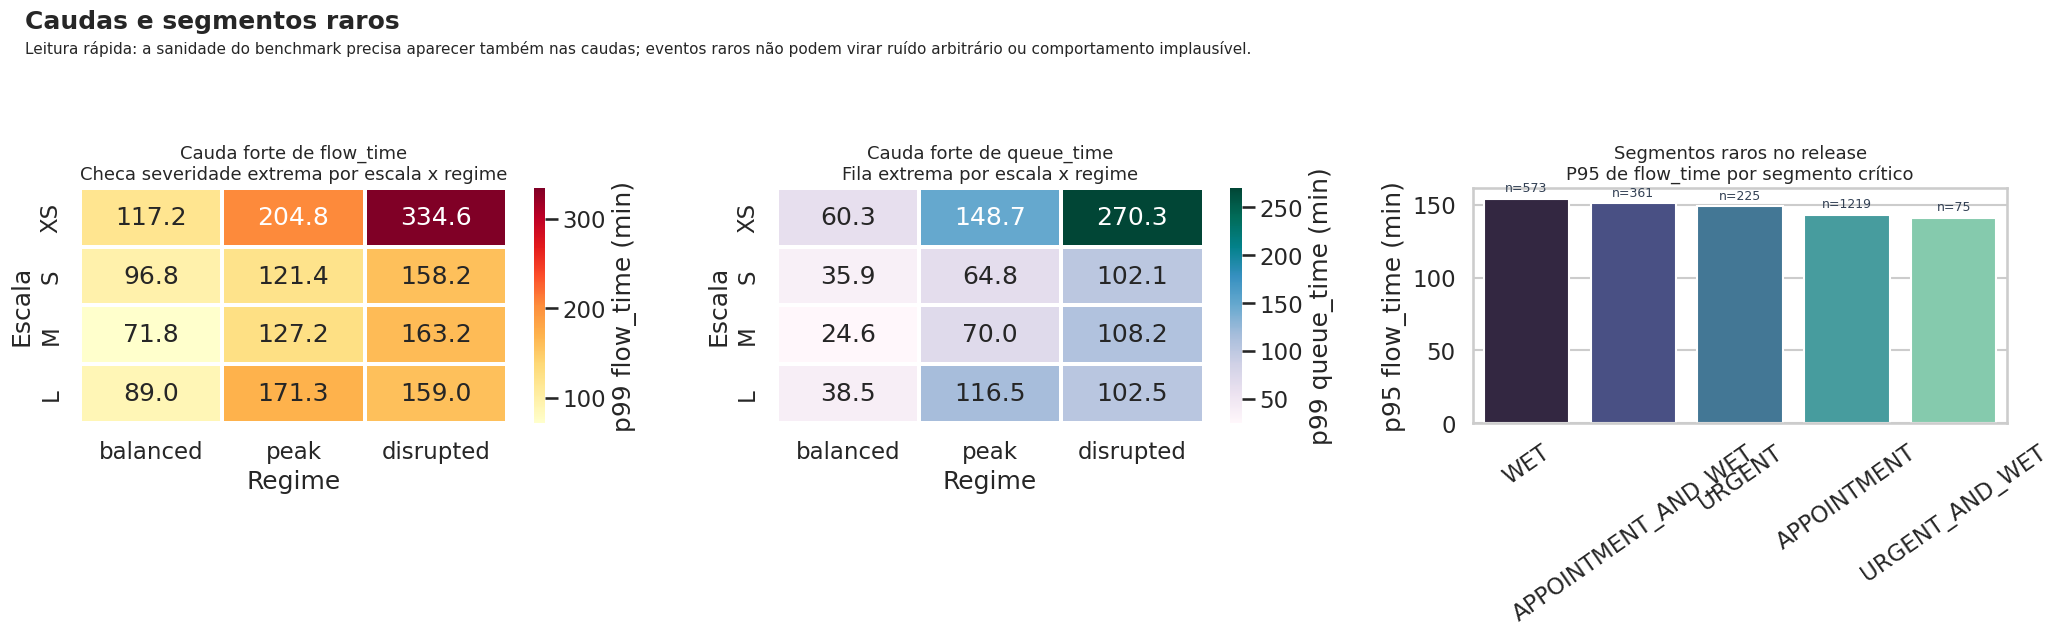

In [12]:
tail_regime_summary, tail_regime_checks, rare_segment_summary = build_tail_and_segment_reports(
    jobs_enriched=jobs_enriched,
    job_metrics=job_metrics,
)
display(tail_regime_summary.sort_values(["scale_code", "regime_code"]))
display(tail_regime_checks.sort_values("scale_code"))
display(rare_segment_summary)

flow_p99_heatmap = (
    tail_regime_summary.pivot(index="scale_code", columns="regime_code", values="flow_p99")
    .reindex(index=SCALE_ORDER, columns=REGIME_ORDER)
)
queue_p99_heatmap = (
    tail_regime_summary.pivot(index="scale_code", columns="regime_code", values="queue_p99")
    .reindex(index=SCALE_ORDER, columns=REGIME_ORDER)
)

fig, axes = plt.subplots(1, 3, figsize=(21, 6.3))
sns.heatmap(
    flow_p99_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=1.5,
    linecolor="white",
    cbar_kws={"label": "p99 flow_time (min)"},
    ax=axes[0],
)
axes[0].set_title("Cauda forte de flow_time\nCheca severidade extrema por escala x regime", fontsize=13)
axes[0].set_xlabel("Regime")
axes[0].set_ylabel("Escala")

sns.heatmap(
    queue_p99_heatmap,
    annot=True,
    fmt=".1f",
    cmap="PuBuGn",
    linewidths=1.5,
    linecolor="white",
    cbar_kws={"label": "p99 queue_time (min)"},
    ax=axes[1],
)
axes[1].set_title("Cauda forte de queue_time\nFila extrema por escala x regime", fontsize=13)
axes[1].set_xlabel("Regime")
axes[1].set_ylabel("Escala")

sns.barplot(
    data=rare_segment_summary,
    x="segment_label",
    y="flow_p95",
    hue="segment_label",
    dodge=False,
    legend=False,
    palette="mako",
    ax=axes[2],
)
axes[2].set_title("Segmentos raros no release\nP95 de flow_time por segmento crítico", fontsize=13)
axes[2].set_xlabel("")
axes[2].set_ylabel("p95 flow_time (min)")
axes[2].tick_params(axis="x", rotation=35)
for patch, (_, row) in zip(axes[2].patches, rare_segment_summary.iterrows()):
    axes[2].text(
        patch.get_x() + patch.get_width() / 2,
        float(row["flow_p95"]) + 3,
        f"n={int(row['job_count'])}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#334155",
    )

fig.suptitle("Caudas e segmentos raros", x=0.02, y=1.02, ha="left", fontsize=18, fontweight="bold")
fig.text(
    0.02,
    0.95,
    "Leitura rápida: a sanidade do benchmark precisa aparecer também nas caudas; eventos raros não podem virar ruído arbitrário ou comportamento implausível.",
    fontsize=11,
)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(ARTIFACT_DIR / "tail_and_rare_segments.png", dpi=160, bbox_inches="tight")
plt.show()

tail_regime_summary.to_csv(ARTIFACT_DIR / "tail_regime_summary.csv", index=False)
tail_regime_checks.to_csv(ARTIFACT_DIR / "tail_regime_checks.csv", index=False)
rare_segment_summary.to_csv(ARTIFACT_DIR / "rare_segment_summary.csv", index=False)

**Como ler a figura acima**

- os dois heatmaps verificam se o gradiente `balanced < peak < disrupted` continua aparecendo também nas caudas `p99`
- a tabela `tail_regime_checks` formaliza essa monotonicidade forte por escala
- o gráfico de segmentos raros ajuda a ver se classes menos frequentes, como `URGENT` e `WET`, preservam comportamento plausível em `flow_time`
- esta seção é importante porque benchmarks sintéticos costumam acertar médias e errar justamente os eventos extremos

## Instance-space coverage and redundancy screening

Além de ser íntegro e executável, o release precisa cobrir regiões distintas do problema.
Para dados sintéticos, isso é crucial: um benchmark só é realmente útil se não colapsar
em um conjunto de instâncias quase idênticas.

Nesta seção, `PCA` e `kNN` cumprem papéis complementares:

- `PCA` testa a cobertura global do espaço de instâncias; ele ajuda a ver se as instâncias ocupam regiões diferentes do problema ou se estão comprimidas em um bloco estreito
- `kNN` testa a redundância local; mesmo quando a projeção em 2D parece boa, as distâncias de vizinhança mostram se há casos quase duplicados
- juntos, eles sustentam uma afirmação metodológica importante para o TCC: o dataset sintético não é apenas válido estruturalmente, mas também suficientemente diverso para funcionar como benchmark

Esta seção responde:

- se há duplicatas exatas no nível de instância
- se há casos "duplicate-like" em um espaço multivariado de features estruturais e operacionais
- quão dispersas as instâncias estão quando projetadas em 2D via PCA
- como as distâncias `kNN` evoluem para `k = 1, 3, 5`
- quão "pura" é a vizinhança em termos de regime e escala
- quais pares são os mais próximos dentro do release

,instance_count,feature_count,pca_pc1_explained_variance_ratio,pca_pc2_explained_variance_ratio,pca_pc1_pc2_explained_variance_ratio,exact_core_duplicate_count,exact_feature_duplicate_count,duplicate_like_threshold,duplicate_like_candidate_count,nearest_neighbor_distance_min,nearest_neighbor_distance_median,nearest_neighbor_distance_max,knn_same_regime_share_k5_mean,knn_same_scale_share_k5_mean
0,36,37,0.332119,0.257029,0.589148,0,0,2.0,0,2.322821,3.569669,6.170144,0.666667,0.683333


,instance_id,scale_code,regime_code,nearest_neighbor_instance_id,nearest_neighbor_distance,duplicate_like_candidate
6,GO_L_PEAK_01,L,peak,GO_L_PEAK_03,2.322821,False
8,GO_L_PEAK_03,L,peak,GO_L_PEAK_01,2.322821,False
5,GO_L_DISRUPTED_03,L,disrupted,GO_L_DISRUPTED_01,2.336918,False
3,GO_L_DISRUPTED_01,L,disrupted,GO_L_DISRUPTED_03,2.336918,False
9,GO_M_BALANCED_01,M,balanced,GO_M_BALANCED_02,2.632649,False
10,GO_M_BALANCED_02,M,balanced,GO_M_BALANCED_01,2.632649,False
7,GO_L_PEAK_02,L,peak,GO_L_PEAK_03,2.754415,False
16,GO_M_PEAK_02,M,peak,GO_M_BALANCED_02,2.766558,False
1,GO_L_BALANCED_02,L,balanced,GO_L_BALANCED_01,2.900777,False
0,GO_L_BALANCED_01,L,balanced,GO_L_BALANCED_02,2.900777,False


,instance_id,scale_code,regime_code,k,mean_knn_distance,max_knn_distance,same_regime_neighbor_share,same_scale_neighbor_share
18,GO_L_PEAK_01,L,peak,1,2.322821,2.322821,1.0,1.0
24,GO_L_PEAK_03,L,peak,1,2.322821,2.322821,1.0,1.0
9,GO_L_DISRUPTED_01,L,disrupted,1,2.336918,2.336918,1.0,1.0
15,GO_L_DISRUPTED_03,L,disrupted,1,2.336918,2.336918,1.0,1.0
27,GO_M_BALANCED_01,M,balanced,1,2.632649,2.632649,1.0,1.0
...,...,...,...,...,...,...,...,...
92,GO_XS_DISRUPTED_01,XS,disrupted,5,6.478725,7.242154,1.0,0.4
107,GO_XS_PEAK_03,XS,peak,5,6.493480,6.794259,0.6,0.6
104,GO_XS_PEAK_02,XS,peak,5,6.835401,7.129260,0.4,0.2
95,GO_XS_DISRUPTED_02,XS,disrupted,5,7.059355,8.017396,0.6,0.8


,source_regime,neighbor_regime,k,share
0,balanced,balanced,5,0.716667
1,balanced,disrupted,5,0.000000
2,balanced,peak,5,0.283333
3,disrupted,balanced,5,0.016667
4,disrupted,disrupted,5,0.766667
5,disrupted,peak,5,0.216667
6,peak,balanced,5,0.316667
7,peak,disrupted,5,0.166667
8,peak,peak,5,0.516667


,instance_a,instance_b,scale_a,scale_b,regime_a,regime_b,distance,duplicate_like_under_threshold
0,GO_L_PEAK_01,GO_L_PEAK_03,L,L,peak,peak,2.322821,False
1,GO_L_DISRUPTED_01,GO_L_DISRUPTED_03,L,L,disrupted,disrupted,2.336918,False
2,GO_M_BALANCED_01,GO_M_BALANCED_02,M,M,balanced,balanced,2.632649,False
3,GO_L_PEAK_02,GO_L_PEAK_03,L,L,peak,peak,2.754415,False
4,GO_M_BALANCED_02,GO_M_PEAK_02,M,M,balanced,peak,2.766558,False
5,GO_L_BALANCED_01,GO_L_BALANCED_02,L,L,balanced,balanced,2.900777,False
6,GO_L_DISRUPTED_02,GO_L_DISRUPTED_03,L,L,disrupted,disrupted,3.016497,False
7,GO_L_PEAK_01,GO_L_PEAK_02,L,L,peak,peak,3.172021,False
8,GO_M_BALANCED_03,GO_M_PEAK_02,M,M,balanced,peak,3.205998,False
9,GO_L_DISRUPTED_01,GO_L_DISRUPTED_02,L,L,disrupted,disrupted,3.364756,False


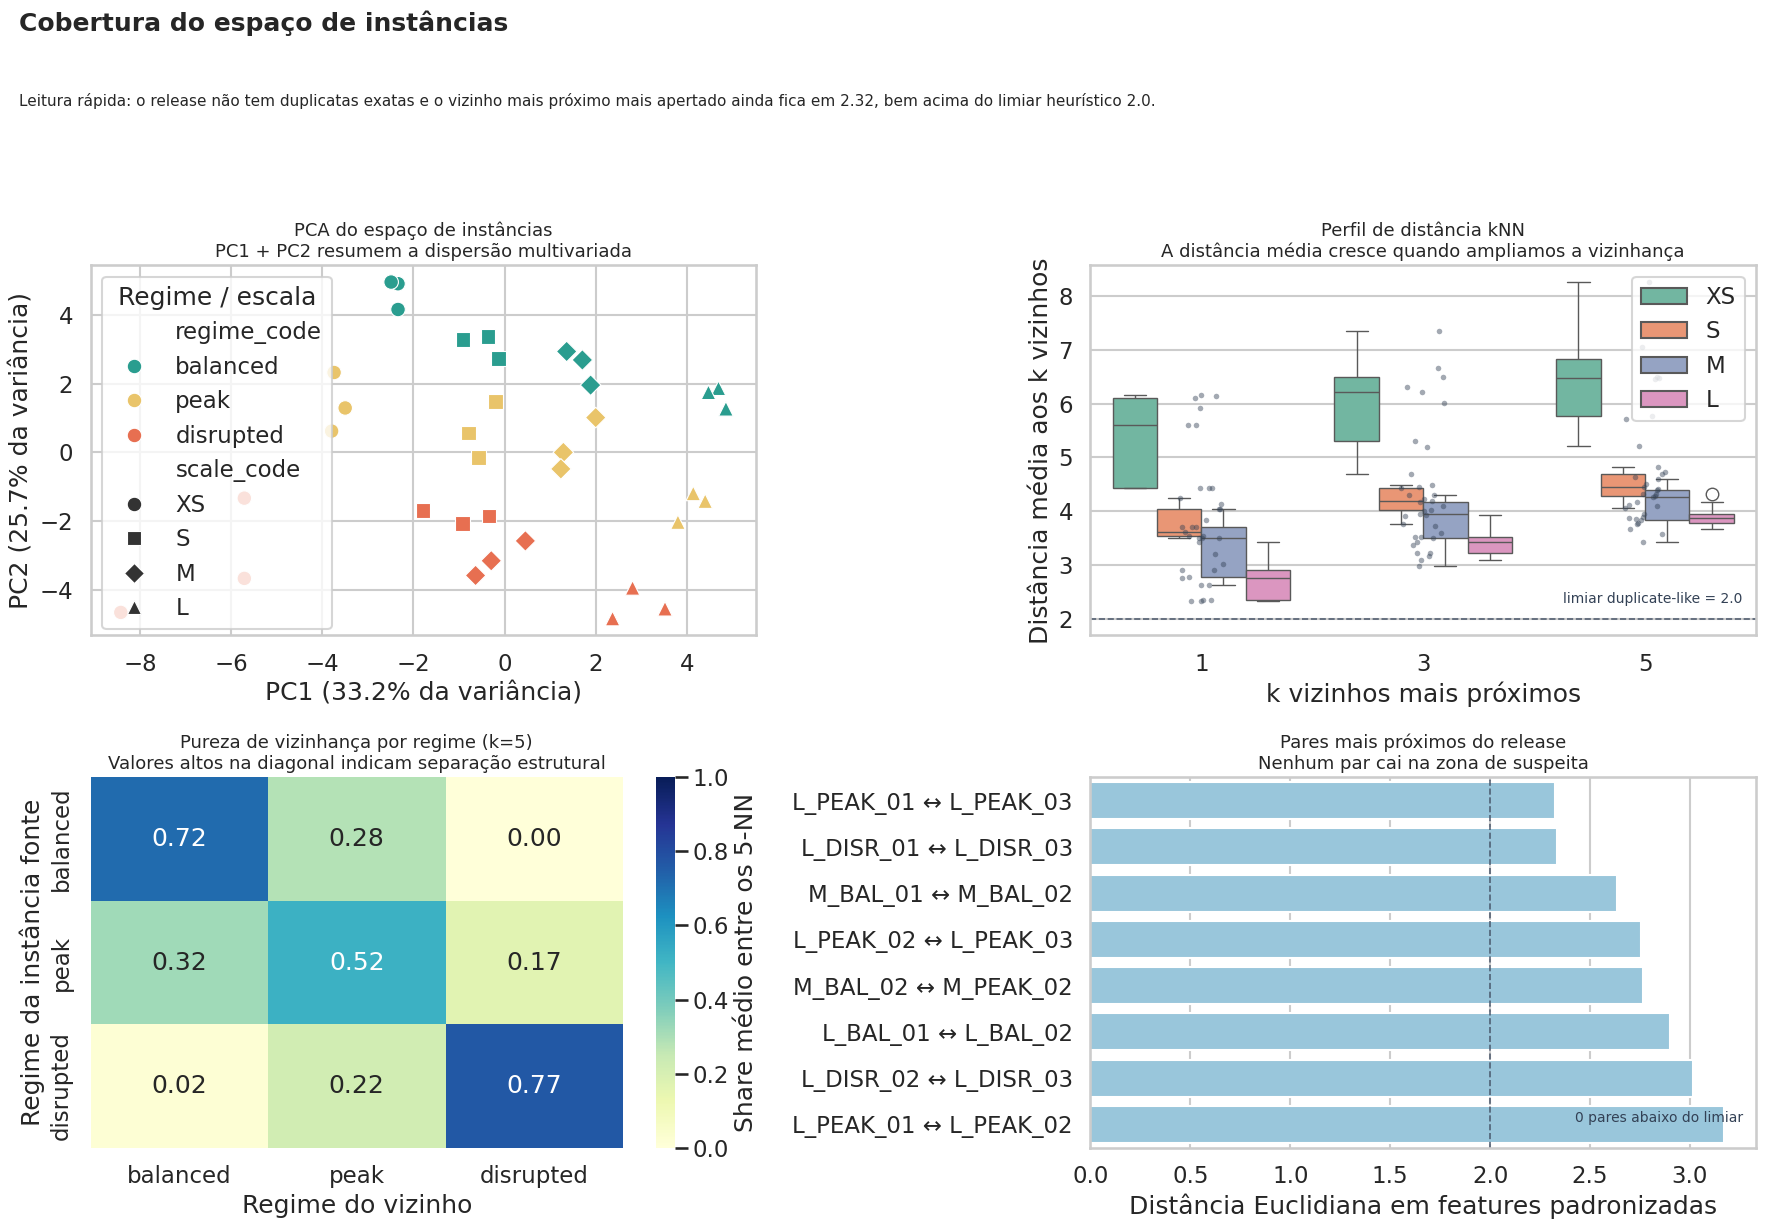


**Por que `PCA` e `kNN` importam para validar dados sintéticos**

- `PCA` fornece uma leitura **global** da cobertura do benchmark. Se todas as instâncias colapsassem na mesma região, o release seria pouco informativo para avaliação algorítmica.
- `kNN` fornece uma leitura **local** de redundância. Mesmo com boa separação visual em 2D, distâncias muito pequenas ainda denunciariam instâncias quase repetidas.
- Os dois testes se complementam: `PCA` responde se o release cobre regiões diferentes do problema, enquanto `kNN` responde se cada instância realmente acrescenta informação nova.
- Neste release, a evidência é favorável: `exact_core_duplicate_count = 0`, `exact_feature_duplicate_count = 0`, `duplicate_like_candidate_count = 0` e `nearest_neighbor_distance_min = 2.3228`.
- Em média, a vizinhança de `5-NN` preserva `same_regime_neighbor_share = 0.6667` e `same_scale_neighbor_share = 0.6833`, o que mostra estrutura sem colapso em duplicatas.


In [13]:
display(instance_space_summary)
display(
    instance_space_features[
        [
            "instance_id",
            "scale_code",
            "regime_code",
            "nearest_neighbor_instance_id",
            "nearest_neighbor_distance",
            "duplicate_like_candidate",
        ]
    ].sort_values("nearest_neighbor_distance")
)
display(instance_space_knn_profile.sort_values(["k", "mean_knn_distance", "instance_id"]))
display(instance_space_knn_regime_composition[instance_space_knn_regime_composition["k"] == 5])
display(instance_space_pairs.head(12))

fig = repl.plot_instance_space_coverage(ctx=NOTEBOOK_CTX, save=True)
plt.show()

instance_space_note = f"""
**Por que `PCA` e `kNN` importam para validar dados sintéticos**

- `PCA` fornece uma leitura **global** da cobertura do benchmark. Se todas as instâncias colapsassem na mesma região, o release seria pouco informativo para avaliação algorítmica.
- `kNN` fornece uma leitura **local** de redundância. Mesmo com boa separação visual em 2D, distâncias muito pequenas ainda denunciariam instâncias quase repetidas.
- Os dois testes se complementam: `PCA` responde se o release cobre regiões diferentes do problema, enquanto `kNN` responde se cada instância realmente acrescenta informação nova.
- Neste release, a evidência é favorável: `exact_core_duplicate_count = {int(instance_space_summary.loc[0, "exact_core_duplicate_count"])}`, `exact_feature_duplicate_count = {int(instance_space_summary.loc[0, "exact_feature_duplicate_count"])}`, `duplicate_like_candidate_count = {int(instance_space_summary.loc[0, "duplicate_like_candidate_count"])}` e `nearest_neighbor_distance_min = {float(instance_space_summary.loc[0, "nearest_neighbor_distance_min"]):.4f}`.
- Em média, a vizinhança de `5-NN` preserva `same_regime_neighbor_share = {float(instance_space_summary.loc[0, "knn_same_regime_share_k5_mean"]):.4f}` e `same_scale_neighbor_share = {float(instance_space_summary.loc[0, "knn_same_scale_share_k5_mean"]):.4f}`, o que mostra estrutura sem colapso em duplicatas.
"""
display(Markdown(instance_space_note))

instance_space_features.to_csv(ARTIFACT_DIR / "instance_space_features.csv", index=False)
instance_space_pairs.to_csv(ARTIFACT_DIR / "instance_space_pairs.csv", index=False)
instance_space_summary.to_csv(ARTIFACT_DIR / "instance_space_summary.csv", index=False)
instance_space_knn_profile.to_csv(ARTIFACT_DIR / "instance_space_knn_profile.csv", index=False)
instance_space_knn_regime_composition.to_csv(ARTIFACT_DIR / "instance_space_knn_regime_composition.csv", index=False)
instance_space_knn_scale_composition.to_csv(ARTIFACT_DIR / "instance_space_knn_scale_composition.csv", index=False)

**Como ler a figura acima**

- painel superior esquerdo: a PCA resume o release em 2 dimensões; ela serve para verificar cobertura global, isto é, se o benchmark ocupa regiões diferentes do espaço de instâncias
- painel superior direito: o perfil `kNN` mostra como a distância média cresce quando ampliamos a vizinhança de `1` para `3` e `5`; ele serve para verificar redundância local
- painel inferior esquerdo: a pureza de vizinhança por regime mostra quanto os `5-NN` tendem a permanecer na mesma família de regime, sem virar um conjunto indistinguível
- painel inferior direito: mostra os pares mais próximos do release; se algum caísse abaixo do limiar, ele apareceria como candidato `duplicate-like`
- a leitura metodológica correta é: `PCA` responde "o release cobre regiões diferentes do problema?" e `kNN` responde "essas regiões contêm instâncias realmente distintas?"
- as tabelas `instance_space_knn_profile` e `instance_space_knn_regime_composition` dão a leitura quantitativa complementar ao PCA

## Solver-oriented smoke test

As seções anteriores mostram que o release é válido e diverso. Esta seção
adiciona uma evidência complementar: o dataset também é informativo para
benchmark algorítmico.

O teste abaixo não é o protocolo final do TCC. Ele é um **smoke test exato
budgetado**, usando `scipy.optimize.milp` neste ambiente porque `gurobipy`
não está disponível localmente. Para manter o tempo de execução sob controle,
usamos subinstâncias induzidas pelos primeiros jobs em ordem de chegada,
com orçamento fixo de `5` segundos por caso.

A leitura desejada é:

- casos pequenos fecham com solver exato
- casos intermediários continuam viáveis, mas passam a exibir gap
- casos maiores seguem carregando e produzindo incumbentes, mas já apontam para trilhas `hybrid` ou `metaheuristic`

,instance_id,scale_code,regime_code,recommended_solver_track,time_limit_sec,max_jobs,status_code,status_label,success,has_solution,objective_makespan_min,dual_bound_makespan_min,mip_gap,wall_time_sec,mip_node_count,job_count,op_count,eligible_var_count,machine_pair_binary_count,downtime_binary_count,constraint_count,case_label,gap_pct,objective_vs_dual_gap_min
0,GO_XS_BALANCED_01,XS,balanced,exact,5.0,8,0,optimal,True,True,378.000000,378.0,0.000000,1.016405,1068,8,32,50,289,0,706,XS-8 jobs,0.000000,0.000000
1,GO_S_BALANCED_01,S,balanced,exact,5.0,12,0,optimal,True,True,327.000000,327.0,0.000000,2.234721,1198,12,48,101,816,0,1824,S-12 jobs,0.000000,0.000000
2,GO_M_BALANCED_01,M,balanced,hybrid,5.0,18,1,time_limit,False,True,484.999999,408.0,0.158763,5.009018,592,18,72,195,2526,0,5340,M-18 jobs,15.876288,76.999999
3,GO_L_BALANCED_01,L,balanced,metaheuristic,5.0,24,1,time_limit,False,True,589.000000,340.0,0.422750,5.164448,448,24,96,351,6122,0,12628,L-24 jobs,42.275042,249.000000


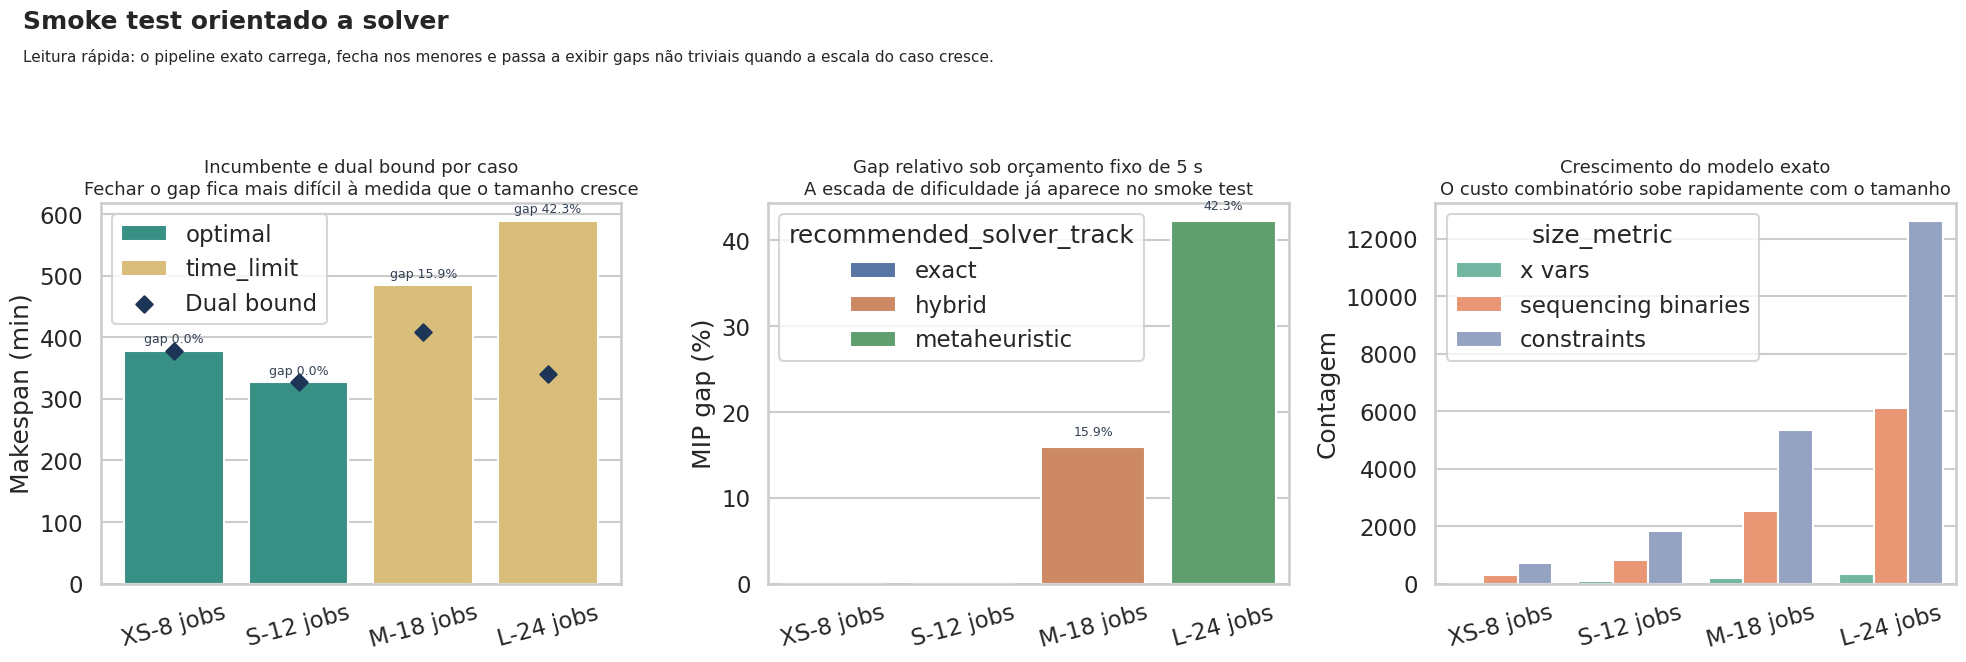

,solver_backend,time_limit_sec,small_cases_optimal,all_cases_have_solution,large_cases_nontrivial_gap,gap_non_decreasing_with_case_size
0,scipy.optimize.milp (HiGHS),5.0,True,True,True,True


In [14]:
solver_smoke_df = solver_smoke.run_smoke_suite(root=REPO_ROOT)
solver_smoke_df["case_label"] = (
    solver_smoke_df["scale_code"].astype(str)
    + "-"
    + solver_smoke_df["max_jobs"].astype(int).astype(str)
    + " jobs"
)
solver_smoke_df["gap_pct"] = solver_smoke_df["mip_gap"].fillna(1.0) * 100.0
solver_smoke_df["objective_vs_dual_gap_min"] = (
    solver_smoke_df["objective_makespan_min"] - solver_smoke_df["dual_bound_makespan_min"]
)

display(solver_smoke_df)

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

sns.barplot(
    data=solver_smoke_df,
    x="case_label",
    y="objective_makespan_min",
    hue="status_label",
    dodge=False,
    palette={"optimal": "#2a9d8f", "time_limit": "#e9c46a", "feasible": "#8ecae6", "other": "#94a3b8", "infeasible": "#d62828"},
    ax=axes[0],
)
axes[0].scatter(
    range(len(solver_smoke_df)),
    solver_smoke_df["dual_bound_makespan_min"],
    color="#1d3557",
    s=70,
    marker="D",
    zorder=3,
    label="Dual bound",
)
for idx, row in solver_smoke_df.reset_index(drop=True).iterrows():
    if pd.notna(row["mip_gap"]):
        axes[0].text(idx, row["objective_makespan_min"] + 8, f"gap {row['mip_gap']:.1%}", ha="center", va="bottom", fontsize=9, color="#334155")
axes[0].set_title("Incumbente e dual bound por caso\nFechar o gap fica mais difícil à medida que o tamanho cresce", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Makespan (min)")
axes[0].tick_params(axis="x", rotation=15)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc="upper left", frameon=True)

sns.barplot(
    data=solver_smoke_df,
    x="case_label",
    y="gap_pct",
    hue="recommended_solver_track",
    dodge=False,
    palette="deep",
    ax=axes[1],
)
axes[1].set_title("Gap relativo sob orçamento fixo de 5 s\nA escada de dificuldade já aparece no smoke test", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("MIP gap (%)")
axes[1].tick_params(axis="x", rotation=15)
for patch in axes[1].patches:
    height = patch.get_height()
    if np.isfinite(height) and height > 0:
        axes[1].text(patch.get_x() + patch.get_width() / 2, height + 1.0, f"{height:.1f}%", ha="center", va="bottom", fontsize=9, color="#334155")

size_plot = solver_smoke_df.melt(
    id_vars=["case_label"],
    value_vars=["eligible_var_count", "machine_pair_binary_count", "constraint_count"],
    var_name="size_metric",
    value_name="count",
)
size_labels = {
    "eligible_var_count": "x vars",
    "machine_pair_binary_count": "sequencing binaries",
    "constraint_count": "constraints",
}
size_plot["size_metric"] = size_plot["size_metric"].map(size_labels)
sns.barplot(
    data=size_plot,
    x="case_label",
    y="count",
    hue="size_metric",
    ax=axes[2],
    palette="Set2",
)
axes[2].set_title("Crescimento do modelo exato\nO custo combinatório sobe rapidamente com o tamanho", fontsize=13)
axes[2].set_xlabel("")
axes[2].set_ylabel("Contagem")
axes[2].tick_params(axis="x", rotation=15)

fig.suptitle("Smoke test orientado a solver", x=0.02, y=1.03, ha="left", fontsize=18, fontweight="bold")
fig.text(
    0.02,
    0.95,
    "Leitura rápida: o pipeline exato carrega, fecha nos menores e passa a exibir gaps não triviais quando a escala do caso cresce.",
    fontsize=11,
)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(ARTIFACT_DIR / "solver_oriented_smoke_test.png", dpi=160, bbox_inches="tight")
plt.show()

solver_smoke_df.to_csv(ARTIFACT_DIR / "solver_smoke_results.csv", index=False)

solver_smoke_summary = pd.DataFrame(
    [
        {
            "solver_backend": "scipy.optimize.milp (HiGHS)",
            "time_limit_sec": float(solver_smoke_df["time_limit_sec"].iloc[0]),
            "small_cases_optimal": bool(
                solver_smoke_df.loc[solver_smoke_df["max_jobs"].isin([8, 12]), "status_label"].eq("optimal").all()
            ),
            "all_cases_have_solution": bool(solver_smoke_df["has_solution"].all()),
            "large_cases_nontrivial_gap": bool(
                solver_smoke_df.loc[solver_smoke_df["max_jobs"].isin([18, 24]), "mip_gap"].fillna(0.0).ge(0.10).all()
            ),
            "gap_non_decreasing_with_case_size": bool(
                solver_smoke_df.sort_values("max_jobs")["mip_gap"].fillna(0.0).is_monotonic_increasing
            ),
        }
    ]
)
display(solver_smoke_summary)
solver_smoke_summary.to_csv(ARTIFACT_DIR / "solver_smoke_summary.csv", index=False)

**Como ler a figura acima**

- painel esquerdo: as barras são os incumbentes e os diamantes são os dual bounds; distância grande entre eles significa dificuldade residual
- painel central: sob o mesmo orçamento de tempo, `XS-8` e `S-12` fecham, enquanto `M-18` e `L-24` já preservam gaps não triviais
- painel direito: o crescimento de binárias disjuntivas e restrições explica por que a trilha recomendada migra de `exact` para `hybrid/metaheuristic`
- esta seção é um **smoke test de utilidade algorítmica**, não o protocolo final de competição entre solvers

## Instance drilldown

Um drilldown ajuda a validar visualmente se o baseline FIFO de uma instância concreta:

- respeita o fluxo por máquina
- evita overlap
- incorpora downtimes
- produz métricas coerentes com o regime escolhido

,dataset_name,dataset_version,instance_id,scale_code,regime_code,replicate,random_seed,time_unit,load_unit,currency,planning_horizon_min,shift_open_min,shift_close_min,antt_statutory_wait_limit_min,antt_wait_cost_rs_per_ton_hour,notes,parent_dataset_version,observational_noise_model_id,observational_noise_seed
30,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_XS_DISRUPTED_01,XS,disrupted,1,11333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,2360242032


,instance_id,relative_path,scale_code,regime_code,replicate,random_seed,n_jobs,n_machines,n_scales,n_labs,n_hoppers,n_breakdowns,share_urgent,share_appointment,avg_load_tons,avg_unload_proc_time_min,fifo_makespan_min,fifo_mean_flow_min,fifo_p95_flow_min,fifo_overwait_share,recommended_solver_track
30,GO_XS_DISRUPTED_01,instances/GO_XS_DISRUPTED_01,XS,disrupted,1,11333,24,5,2,1,2,2,0.2083,0.4583,38.33,34.12,717,140.71,288,0.0417,exact


,job_id,commodity,load_tons,arrival_time_min,reveal_time_min,priority_class,priority_weight,appointment_flag,moisture_class,statutory_wait_limit_min,completion_due_min,overwait_cost_rs_per_min,shift_bucket,arrival_congestion_score,instance_id,scale_code,regime_code,replicate,dataset_version,nominal_lb_min,due_slack_min,due_margin_over_lb_min,reveal_lead_min
1704,J0001,SOY,35,37,37,CONTRACTED,1.25,0,NORMAL,300,343,1.4058,EARLY,0.322444,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,57,306,249,0
1705,J0002,SORGHUM,31,68,68,REGULAR,1.00,0,WET,300,413,1.2452,EARLY,0.820252,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,61,345,284,0
1706,J0003,CORN,45,70,7,CONTRACTED,1.25,1,NORMAL,300,340,1.8075,EARLY,0.842879,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,60,270,210,63
1707,J0004,CORN,35,71,64,URGENT,1.75,1,NORMAL,300,318,1.4058,EARLY,0.848536,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,53,247,194,7
1708,J0005,CORN,44,73,73,REGULAR,1.00,0,NORMAL,300,409,1.7673,EARLY,0.848536,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,62,336,274,0


,completion_min,flow_time_min,queue_time_min,overwait_min,replicate
count,24.00,24.00,24.00,24.00,24.0
mean,369.42,140.71,78.92,1.42,1.0
std,190.25,71.99,71.23,6.94,0.0
min,94.00,57.00,0.00,0.00,1.0
25%,211.00,93.50,31.75,0.00,1.0
50%,354.50,126.50,66.50,0.00,1.0
75%,497.50,162.50,106.00,0.00,1.0
max,717.00,334.00,268.00,34.00,1.0


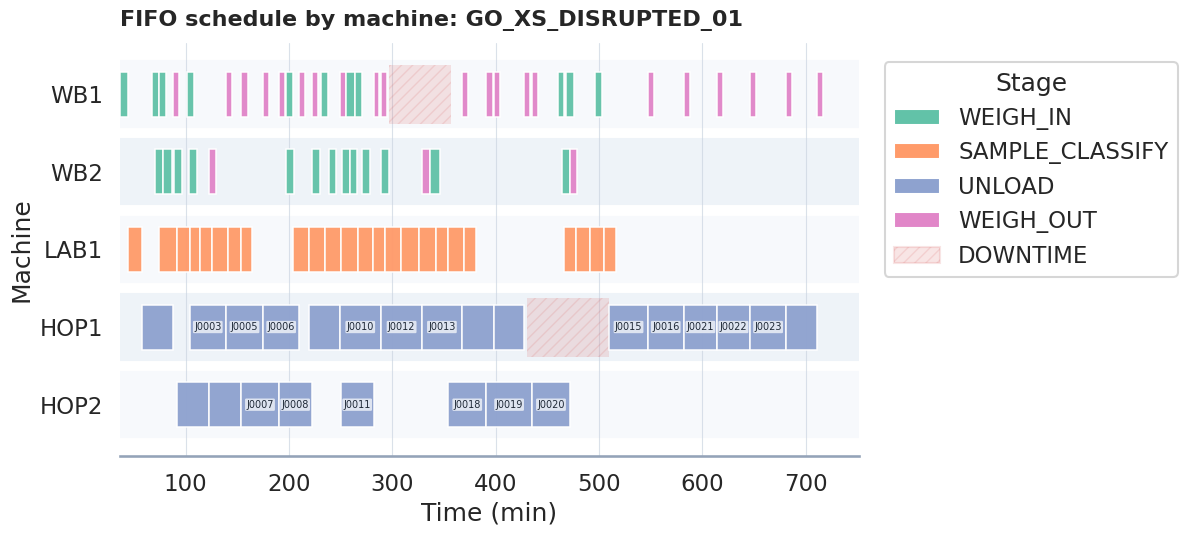

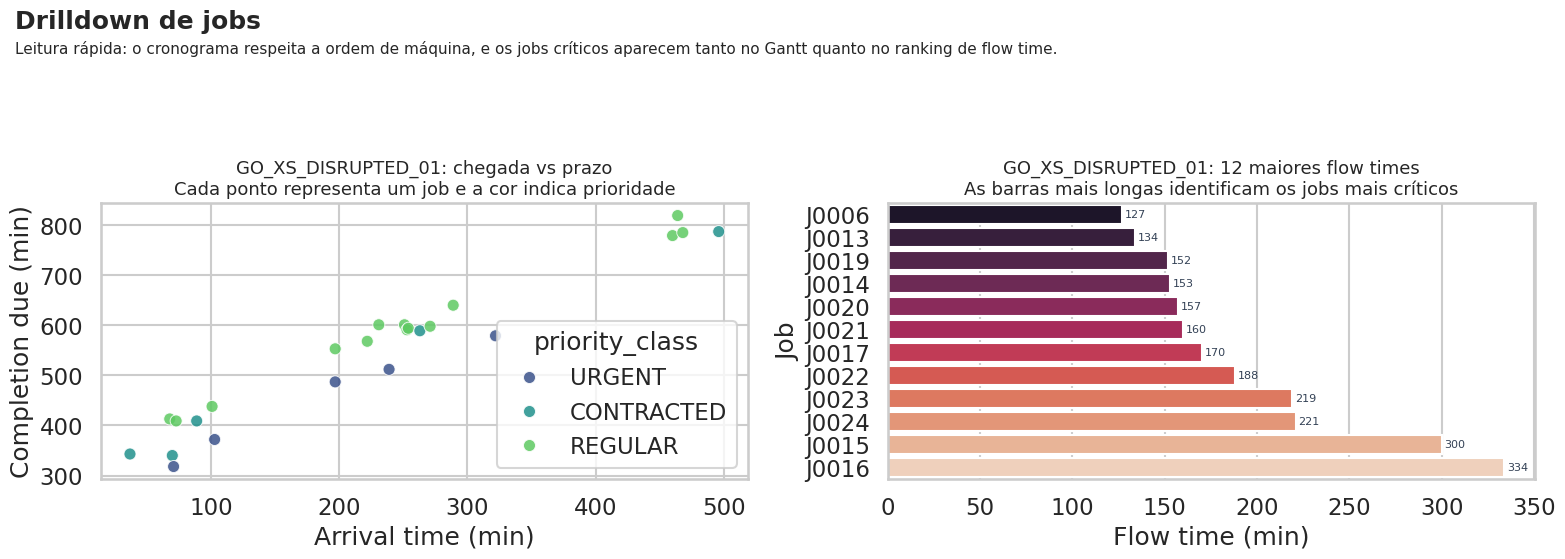

In [15]:
sample_instance = "GO_XS_DISRUPTED_01"

sample_params = params[params["instance_id"] == sample_instance]
sample_summary = catalog[catalog["instance_id"] == sample_instance]
sample_jobs = jobs_enriched[jobs_enriched["instance_id"] == sample_instance]
sample_metrics = job_metrics[job_metrics["instance_id"] == sample_instance]

display(sample_params)
display(sample_summary)
display(sample_jobs.head())
display(sample_metrics.describe().round(2))

fig = repl.plot_instance_drilldown(sample_instance, ctx=NOTEBOOK_CTX, save=True)
plt.show()

fig = repl.plot_job_level_views(sample_instance, ctx=NOTEBOOK_CTX, save=True)
plt.show()

**Como ler as figuras acima**

- o Gantt mostra ocupação por máquina, faixas de downtime e ausência de overlap no baseline FIFO
- o scatter de jobs ajuda a ver como os prazos se distribuem em função da chegada
- o ranking horizontal destaca os jobs mais críticos em `flow_time`

## Results and notes

O notebook consolida uma leitura de qualidade do release oficial:

- o release está estruturalmente íntegro
- o release também é relacionalmente consistente entre arquivos, chaves e cardinalidades
- o baseline FIFO é executável contra o schema nas `36` instâncias
- os audits reconciliam os valores centrais
- os checks de regime são positivos para `mean_flow`, `p95_flow` e fila média
- o proxy médio de congestionamento é útil, mas não monotônico em todas as famílias
- a camada observacional produz um deslocamento formalmente detectável por `C2ST/MMD`, mas ainda interpretável
- as caudas `p99` e os segmentos raros continuam sob controle analítico
- o espaço de instâncias não contém duplicatas exatas nem candidatos `duplicate-like` sob o screening adotado
- `PCA` e `kNN` mostram, de forma complementar, que o release tem cobertura global e baixa redundância local
- o smoke test exato fecha nos casos menores e exibe gaps não triviais quando o tamanho da subinstância cresce
- a camada observacional reduz determinismo excessivo sem destruir semântica
- a base é forte o suficiente para servir como dataset pai de análises e futuras derivações com G2MILP

In [16]:
summary = {
    "dataset_version": manifest["dataset_version"],
    "instance_count": int(params["instance_id"].nunique()),
    "structural_pass_rate": float((structural_report["status"] == "PASS").mean()),
    "release_consistency_checks_pass": bool(release_consistency_report["pass"].all()),
    "relational_consistency_checks_pass": bool(relational_consistency_summary["pass_rate"].eq(1.0).all()),
    "fifo_schema_checks_pass": bool(
        fifo_schema_report[
            [
                "eligible_assignment_ok",
                "release_time_ok",
                "precedence_ok",
                "machine_overlap_ok",
                "downtime_ok",
            ]
        ].all(axis=None)
    ),
    "due_audit_match_share": float(audit_reconciliation["due_match_share"].mean()),
    "proc_audit_match_share": float(audit_reconciliation["proc_match_share"].mean()),
    "r2_due_slack_vs_priority": float(diagnostics["r2_due_slack_vs_priority"]),
    "r2_unload_proc_vs_load_machine_moisture": float(
        diagnostics["r2_unload_proc_vs_load_machine_moisture"]
    ),
    "flow_regime_order_checks_pass": bool(
        regime_checks["mean_flow_order_ok"].all()
        and regime_checks["p95_flow_order_ok"].all()
    ),
    "queue_regime_order_checks_pass": bool(regime_checks["mean_queue_order_ok"].all()),
    "congestion_mean_regime_order_checks_pass": bool(
        regime_checks["mean_congestion_order_ok"].all()
    ),
    "instance_space_exact_duplicate_checks_pass": bool(
        instance_space_summary.loc[0, "exact_core_duplicate_count"] == 0
        and instance_space_summary.loc[0, "exact_feature_duplicate_count"] == 0
    ),
    "instance_space_duplicate_like_checks_pass": bool(
        instance_space_summary.loc[0, "duplicate_like_candidate_count"] == 0
    ),
    "instance_space_nearest_neighbor_distance_min": float(
        instance_space_summary.loc[0, "nearest_neighbor_distance_min"]
    ),
    "job_due_c2st_auc_mean": float(
        formal_shift_summary.loc[
            formal_shift_summary["experiment"].eq("job_due_layer"), "c2st_auc_mean"
        ].iloc[0]
    ),
    "proc_time_c2st_auc_mean": float(
        formal_shift_summary.loc[
            formal_shift_summary["experiment"].eq("proc_time_layer"), "c2st_auc_mean"
        ].iloc[0]
    ),
    "tail_flow_p99_regime_order_checks_pass": bool(tail_regime_checks["flow_p99_order_ok"].all()),
    "tail_queue_p99_regime_order_checks_pass": bool(tail_regime_checks["queue_p99_order_ok"].all()),
    "tail_due_margin_p05_regime_order_checks_pass": bool(
        tail_regime_checks["due_margin_p05_order_ok"].all()
    ),
    "solver_smoke_small_cases_optimal": bool(
        solver_smoke_summary.loc[0, "small_cases_optimal"]
    ),
    "solver_smoke_all_cases_have_solution": bool(
        solver_smoke_summary.loc[0, "all_cases_have_solution"]
    ),
    "solver_smoke_large_cases_nontrivial_gap": bool(
        solver_smoke_summary.loc[0, "large_cases_nontrivial_gap"]
    ),
    "solver_smoke_gap_ladder_pass": bool(
        solver_smoke_summary.loc[0, "gap_non_decreasing_with_case_size"]
    ),
    "g2milp_role": manifest["official_dataset_role"],
}
summary_df = pd.DataFrame([summary])
display(summary_df)

summary_lines = [
    "# Notebook Summary",
    "",
    f"- Dataset version: `{summary['dataset_version']}`",
    f"- Instances: `{summary['instance_count']}`",
    f"- Structural pass rate: `{summary['structural_pass_rate']:.4f}`",
    f"- Release consistency checks pass: `{summary['release_consistency_checks_pass']}`",
    f"- Relational consistency checks pass: `{summary['relational_consistency_checks_pass']}`",
    f"- FIFO schema checks pass: `{summary['fifo_schema_checks_pass']}`",
    f"- Due audit match share: `{summary['due_audit_match_share']:.4f}`",
    f"- Proc audit match share: `{summary['proc_audit_match_share']:.4f}`",
    f"- R2 due slack vs priority: `{summary['r2_due_slack_vs_priority']:.4f}`",
    f"- R2 unload proc vs load+machine+moisture: `{summary['r2_unload_proc_vs_load_machine_moisture']:.4f}`",
    f"- Flow regime checks pass: `{summary['flow_regime_order_checks_pass']}`",
    f"- Mean queue regime checks pass: `{summary['queue_regime_order_checks_pass']}`",
    f"- Mean congestion regime checks pass: `{summary['congestion_mean_regime_order_checks_pass']}`",
    f"- Instance-space exact duplicate checks pass: `{summary['instance_space_exact_duplicate_checks_pass']}`",
    f"- Instance-space duplicate-like checks pass: `{summary['instance_space_duplicate_like_checks_pass']}`",
    f"- Instance-space nearest-neighbor distance min: `{summary['instance_space_nearest_neighbor_distance_min']:.4f}`",
    f"- Job due-layer C2ST AUC mean: `{summary['job_due_c2st_auc_mean']:.4f}`",
    f"- Proc-time layer C2ST AUC mean: `{summary['proc_time_c2st_auc_mean']:.4f}`",
    f"- Tail flow p99 regime checks pass: `{summary['tail_flow_p99_regime_order_checks_pass']}`",
    f"- Tail queue p99 regime checks pass: `{summary['tail_queue_p99_regime_order_checks_pass']}`",
    f"- Tail due-margin p05 regime checks pass: `{summary['tail_due_margin_p05_regime_order_checks_pass']}`",
    f"- Solver smoke small cases optimal: `{summary['solver_smoke_small_cases_optimal']}`",
    f"- Solver smoke all cases have solution: `{summary['solver_smoke_all_cases_have_solution']}`",
    f"- Solver smoke large cases show non-trivial gap: `{summary['solver_smoke_large_cases_nontrivial_gap']}`",
    f"- Solver smoke gap ladder pass: `{summary['solver_smoke_gap_ladder_pass']}`",
    f"- Official role: `{summary['g2milp_role']}`",
]
summary_text = "\n".join(summary_lines)
(ARTIFACT_DIR / "notebook_summary.md").write_text(summary_text, encoding="utf-8")
summary_df.to_csv(ARTIFACT_DIR / "notebook_summary.csv", index=False)
display(Markdown(summary_text))

,dataset_version,instance_count,structural_pass_rate,release_consistency_checks_pass,relational_consistency_checks_pass,fifo_schema_checks_pass,due_audit_match_share,proc_audit_match_share,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture,flow_regime_order_checks_pass,queue_regime_order_checks_pass,congestion_mean_regime_order_checks_pass,instance_space_exact_duplicate_checks_pass,instance_space_duplicate_like_checks_pass,instance_space_nearest_neighbor_distance_min,job_due_c2st_auc_mean,proc_time_c2st_auc_mean,tail_flow_p99_regime_order_checks_pass,tail_queue_p99_regime_order_checks_pass,tail_due_margin_p05_regime_order_checks_pass,solver_smoke_small_cases_optimal,solver_smoke_all_cases_have_solution,solver_smoke_large_cases_nontrivial_gap,solver_smoke_gap_ladder_pass,g2milp_role
0,1.1.0-observed,36,1.0,True,True,True,1.0,1.0,0.4848,0.4995,True,True,False,True,True,2.322821,0.777706,0.597995,False,False,False,True,True,True,True,base_dataset_for_g2milp_instance_generation


# Notebook Summary

- Dataset version: `1.1.0-observed`
- Instances: `36`
- Structural pass rate: `1.0000`
- Release consistency checks pass: `True`
- Relational consistency checks pass: `True`
- FIFO schema checks pass: `True`
- Due audit match share: `1.0000`
- Proc audit match share: `1.0000`
- R2 due slack vs priority: `0.4848`
- R2 unload proc vs load+machine+moisture: `0.4995`
- Flow regime checks pass: `True`
- Mean queue regime checks pass: `True`
- Mean congestion regime checks pass: `False`
- Instance-space exact duplicate checks pass: `True`
- Instance-space duplicate-like checks pass: `True`
- Instance-space nearest-neighbor distance min: `2.3228`
- Job due-layer C2ST AUC mean: `0.7777`
- Proc-time layer C2ST AUC mean: `0.5980`
- Tail flow p99 regime checks pass: `False`
- Tail queue p99 regime checks pass: `False`
- Tail due-margin p05 regime checks pass: `False`
- Solver smoke small cases optimal: `True`
- Solver smoke all cases have solution: `True`
- Solver smoke large cases show non-trivial gap: `True`
- Solver smoke gap ladder pass: `True`
- Official role: `base_dataset_for_g2milp_instance_generation`

## Next steps

- usar este notebook como baseline de validação antes de gerar filhos com G2MILP
- ampliar com comparações entre esta release oficial e futuros datasets derivados
- adicionar testes de sensibilidade por família de máquina ou por política de geração